# Convolutional Neural Network - Sigmoid


### Import Packages


In [11]:
import os
import time
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.optimizers import Adam
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, UpSampling1D
from tensorflow.keras.utils import Sequence
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# from tensorflow.keras.callbacks import Callback
from scipy.stats import skew, kurtosis

## Check If GPU Enabled

Latest functioning version set as of October 6, 2024 according to https://www.tensorflow.org/install/source_windows is

-   Python 3.10.11
-   Tensorflow 2.10
-   CUDA Toolkit 11.2
-   CUDNN 8.1


In [12]:
# tf.debugging.set_log_device_placement(True) # For Verbose Output
print("Version: ", tf.__version__)
print("Num GPUs Available: ", tf.config.list_physical_devices("GPU"))
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print("TensorFlow is using GPU")
    for gpu in gpus:
        print(gpu.name)
else:
    print("TensorFlow is not using GPU")

Version:  2.17.0
Num GPUs Available:  []
TensorFlow is not using GPU


## Metric Evaluation


In [13]:
# class MetricsCallback(Callback):
#     def __init__(self, test_data, y_true):
#         self.y_true = y_true
#         self.test_data = test_data

#     def on_epoch_end(self, epoch, logs=None):
#         y_pred = self.model.predict(self.test_data)
#         y_pred = tf.argmax(y_pred, axis=1)

#         report_dictionary = classification_report(self.y_true, y_pred, output_dict=True)
#         print(classification_report(self.y_true, y_pred, output_dict=False))

## Binary Pick Mars or Moon


In [14]:
moon = True
train = True
use_processed_data = True

if moon and not train:
    test_set = [
        "S12_GradeB/",
        "S15_GradeA/",
        "S15_GradeB/",
        "S16_GradeA/",
        "S16_GradeB/",
    ][0]

## Hyperparameters


In [15]:
windows_size = 64
batch_size = 500  # 20
label_smoothing = 0.02
n_epochs = 10
dropout = 0.5
# learning_rate = 0.01

if moon:
    freq = 6.625
else:
    freq = 20

input_model_training_size = 3

# kernel_size = [7, 1]
# pool_size = [4, 1]
# decay_step = 1e9
# decay_rate = 0.9
# drop_rate = 0

## Pick Datasets to Train or Test


In [16]:
if use_processed_data:
    if train:
        if moon:
            lunar_train_dir = r"../../data/processed/lunar/train/data/S12_GradeA"
            num_of_events = len(
                [file for file in os.listdir(lunar_train_dir) if file.endswith(".csv")]
            )
            print("Lunar Number of Events: ", num_of_events)
            event = [i for i in range(num_of_events)]  # num_of_events

        else:
            mars_train_dir = r"../../data/processed/mars/train/data/"
            num_of_events = len(
                [file for file in os.listdir(mars_train_dir) if file.endswith(".csv")]
            )
            print("Mars Number of Events: ", num_of_events)
            event = [i for i in range(num_of_events)]  # num_of_events

    else:
        if moon:
            lunar_test_dir = r"../../data/processed/lunar/test/data/" + test_set
            num_of_events = len(
                [file for file in os.listdir(lunar_test_dir) if file.endswith(".csv")]
            )
            print("Lunar Number of Events: ", num_of_events)
            event = [i for i in range(num_of_events)]  # num_of_events

        else:
            mars_test_dir = r"../../data/processed/mars/test/data/"
            num_of_events = len(
                [file for file in os.listdir(mars_test_dir) if file.endswith(".csv")]
            )
            print("Mars Number of Events: ", num_of_events)
            event = [i for i in range(num_of_events)]  # num_of_events

else:
    if train:
        if moon:
            lunar_train_dir = r"../../data/lunar/training/data/S12_GradeA"
            num_of_events = len(
                [file for file in os.listdir(lunar_train_dir) if file.endswith(".csv")]
            )
            print("Lunar Number of Events: ", num_of_events)
            event = [i for i in range(5)]  # num_of_events

        else:
            mars_train_dir = r"../../data/mars/training/data/"
            num_of_events = len(
                [file for file in os.listdir(mars_train_dir) if file.endswith(".csv")]
            )
            print("Mars Number of Events: ", num_of_events)
            event = [i for i in range(num_of_events)]  # num_of_events

    else:
        if moon:
            lunar_test_dir = r"../../data/lunar/test/data/" + test_set
            num_of_events = len(
                [file for file in os.listdir(lunar_test_dir) if file.endswith(".csv")]
            )
            print("Lunar Number of Events: ", num_of_events)
            event = [i for i in range(num_of_events)]  # num_of_events

        else:
            mars_test_dir = r"../../data/mars/test/data/"
            num_of_events = len(
                [file for file in os.listdir(mars_test_dir) if file.endswith(".csv")]
            )
            print("Mars Number of Events: ", num_of_events)
            event = [i for i in range(num_of_events)]  # num_of_events

Lunar Number of Events:  76


## Import Catalog


In [17]:
if train:
    if moon:
        catalog_path = (
            r"../../data/lunar/training/catalogs/apollo12_catalog_GradeA_final.csv"
        )
        catalog = pd.read_csv(catalog_path)

    else:
        catalog_path = (
            r"../../data/mars/training/catalogs/Mars_InSight_training_catalog_final.csv"
        )
        catalog = pd.read_csv(catalog_path)

    print(catalog)

                                  filename time_abs(%Y-%m-%dT%H:%M:%S.%f)  \
0   xa.s12.00.mhz.1970-01-19HR00_evid00002     1970-01-19T20:25:00.000000   
1   xa.s12.00.mhz.1970-03-25HR00_evid00003     1970-03-25T03:32:00.000000   
2   xa.s12.00.mhz.1970-03-26HR00_evid00004     1970-03-26T20:17:00.000000   
3   xa.s12.00.mhz.1970-04-25HR00_evid00006     1970-04-25T01:14:00.000000   
4   xa.s12.00.mhz.1970-04-26HR00_evid00007     1970-04-26T14:29:00.000000   
..                                     ...                            ...   
71  xa.s12.00.mhz.1974-10-14HR00_evid00156     1974-10-14T17:43:00.000000   
72  xa.s12.00.mhz.1975-04-12HR00_evid00191     1975-04-12T18:15:00.000000   
73  xa.s12.00.mhz.1975-05-04HR00_evid00192     1975-05-04T10:05:00.000000   
74  xa.s12.00.mhz.1975-06-24HR00_evid00196     1975-06-24T16:03:00.000000   
75  xa.s12.00.mhz.1975-06-26HR00_evid00198     1975-06-26T03:24:00.000000   

    time_rel(sec)       evid    mq_type  
0         73500.0  evid00002  imp

## Get Filename and, if train, Anomaly Position


In [18]:
if train:
    if moon:
        event_filename = [catalog["filename"][i] + r".csv" for i in event]
        print("Event Filenames:", event_filename)

        true_anomaly_time = [int(catalog["time_rel(sec)"][i]) for i in event]
        print("Anomaly Positions in Each File:", true_anomaly_time)

    else:
        event_filename = [catalog["filename"][i] for i in event]
        print("Event Filenames:", event_filename)

        true_anomaly_time = [int(catalog["time_rel(sec)"][i]) for i in event]
        print("Anomaly Positions in Each File:", true_anomaly_time)

else:
    if moon:
        event_filename = [
            file for file in os.listdir(lunar_test_dir) if file.endswith(".csv")
        ]
        print("Event Filenames:", event_filename)

    else:
        event_filename = [
            file for file in os.listdir(mars_test_dir) if file.endswith(".csv")
        ]
        print("Event Filenames:", event_filename)

Event Filenames: ['xa.s12.00.mhz.1970-01-19HR00_evid00002.csv', 'xa.s12.00.mhz.1970-03-25HR00_evid00003.csv', 'xa.s12.00.mhz.1970-03-26HR00_evid00004.csv', 'xa.s12.00.mhz.1970-04-25HR00_evid00006.csv', 'xa.s12.00.mhz.1970-04-26HR00_evid00007.csv', 'xa.s12.00.mhz.1970-06-15HR00_evid00008.csv', 'xa.s12.00.mhz.1970-06-26HR00_evid00009.csv', 'xa.s12.00.mhz.1970-07-20HR00_evid00010.csv', 'xa.s12.00.mhz.1970-07-20HR00_evid00011.csv', 'xa.s12.00.mhz.1970-09-26HR00_evid00013.csv', 'xa.s12.00.mhz.1970-10-24HR00_evid00014.csv', 'xa.s12.00.mhz.1970-11-12HR00_evid00015.csv', 'xa.s12.00.mhz.1970-12-11HR00_evid00017.csv', 'xa.s12.00.mhz.1970-12-27HR00_evid00019.csv', 'xa.s12.00.mhz.1970-12-31HR00_evid00021.csv', 'xa.s12.00.mhz.1971-01-15HR00_evid00022.csv', 'xa.s12.00.mhz.1971-01-28HR00_evid00023.csv', 'xa.s12.00.mhz.1971-01-29HR00_evid00024.csv', 'xa.s12.00.mhz.1971-02-09HR00_evid00026.csv', 'xa.s12.00.mhz.1971-03-25HR00_evid00028.csv', 'xa.s12.00.mhz.1971-04-13HR00_evid00029.csv', 'xa.s12.00.mhz.1

## Load Data


In [19]:
if use_processed_data:
    if train:
        if moon:
            csv_files_path = r"../../data/processed/lunar/train/data/S12_GradeA"
            csv_files = [os.path.join(csv_files_path, file) for file in event_filename]
            print(csv_files)
        else:
            csv_files_path = r"../../data/processed/mars/train/data"
            csv_files = [os.path.join(csv_files_path, file) for file in event_filename]
            print(csv_files)

    else:
        if moon:
            csv_files_path = r"../../data/processed/lunar/test/data/" + test_set
            csv_files = [os.path.join(csv_files_path, file) for file in event_filename]
            print(csv_files)
        else:
            csv_files_path = r"../../data/processed/mars/test/data/"
            csv_files = [os.path.join(csv_files_path, file) for file in event_filename]
            print(csv_files)

else:
    if train:
        if moon:
            csv_files_path = r"../../data/lunar/training/data/S12_GradeA"
            csv_files = [os.path.join(csv_files_path, file) for file in event_filename]
            print(csv_files)
        else:
            csv_files_path = r"../../data/mars/training/data"
            csv_files = [os.path.join(csv_files_path, file) for file in event_filename]
            print(csv_files)

    else:
        if moon:
            csv_files_path = r"../../data/lunar/test/data/" + test_set
            csv_files = [os.path.join(csv_files_path, file) for file in event_filename]
            print(csv_files)
        else:
            csv_files_path = r"../../data/mars/test/data/"
            csv_files = [os.path.join(csv_files_path, file) for file in event_filename]
            print(csv_files)

['../../data/processed/lunar/train/data/S12_GradeA\\xa.s12.00.mhz.1970-01-19HR00_evid00002.csv', '../../data/processed/lunar/train/data/S12_GradeA\\xa.s12.00.mhz.1970-03-25HR00_evid00003.csv', '../../data/processed/lunar/train/data/S12_GradeA\\xa.s12.00.mhz.1970-03-26HR00_evid00004.csv', '../../data/processed/lunar/train/data/S12_GradeA\\xa.s12.00.mhz.1970-04-25HR00_evid00006.csv', '../../data/processed/lunar/train/data/S12_GradeA\\xa.s12.00.mhz.1970-04-26HR00_evid00007.csv', '../../data/processed/lunar/train/data/S12_GradeA\\xa.s12.00.mhz.1970-06-15HR00_evid00008.csv', '../../data/processed/lunar/train/data/S12_GradeA\\xa.s12.00.mhz.1970-06-26HR00_evid00009.csv', '../../data/processed/lunar/train/data/S12_GradeA\\xa.s12.00.mhz.1970-07-20HR00_evid00010.csv', '../../data/processed/lunar/train/data/S12_GradeA\\xa.s12.00.mhz.1970-07-20HR00_evid00011.csv', '../../data/processed/lunar/train/data/S12_GradeA\\xa.s12.00.mhz.1970-09-26HR00_evid00013.csv', '../../data/processed/lunar/train/data/

## Get Length, Time, and Speed of Each Event

Load all .csv's into one dataframe. Additionally, take the standard normal value of the velocity values, _i.e._

$$
    X_{standard} = \frac{X - \mu_X}{\sigma_X}.
$$


In [20]:
lens_array = []
time_abs_arrays = []
time_arrays = []
data_arrays = []
for file in csv_files:
    df = pd.read_csv(file)

    lens_array.append(len(df))

    if moon:
        time_abs = df["time_abs(%Y-%m-%dT%H:%M:%S.%f)"].values
        time_abs_arrays.append(time_abs)

        t = df["time_rel(sec)"].values
        time_arrays.append(t)

        X = df["velocity(m/s)"].values
        X_standard = (X - np.mean(X)) / np.std(X)
        data_arrays.append(X_standard)
    else:
        time_abs = df["time(%Y-%m-%dT%H:%M:%S.%f)"].values
        time_abs_arrays.append(time_abs)

        t = df["rel_time(sec)"].values
        time_arrays.append(t)

        X = df["velocity(c/s)"].values
        X_standard = (X - np.mean(X)) / np.std(X)
        data_arrays.append(X_standard)

time_abs_array = np.concatenate(time_abs_arrays)
time_array = np.concatenate(time_arrays)
data_array = np.concatenate(data_arrays)

if moon:
    time_abs = pd.DataFrame(time_abs_array, columns=["time_abs(%Y-%m-%dT%H:%M:%S.%f)"])
    time = pd.DataFrame(time_array, columns=["time_rel(sec)"])
    seismic_data = pd.DataFrame(data_array, columns=["velocity(m/s)"])
else:
    time_abs = pd.DataFrame(time_abs_array, columns=["time(%Y-%m-%dT%H:%M:%S.%f)"])
    time = pd.DataFrame(time_array, columns=["rel_time(sec)"])
    seismic_data = pd.DataFrame(data_array, columns=["velocity(c/s)"])

# print("Time Shape: ", np.array(time_arrays).shape)

## Data Preparation


In [21]:
if moon:
    X_standard = seismic_data["velocity(m/s)"].values
else:
    X_standard = seismic_data["velocity(c/s)"].values


X_standard = X_standard.astype(np.float32)  # To save memory

## Create Window Sequences


In [22]:
windows = []
for i in range(len(X_standard) - windows_size):
    windows.append(X_standard[i : i + windows_size])

windows = np.array(windows)

In [23]:
print(windows.shape)

(43175365, 64)


## Get True Anomaly Labels

Places a 0 in `y` for all the values before `anomaly_pos` and 1 for all the values after `anomaly_pos`. Creates a sigmoid labelling.

### Label Type

Pick from four different label types:

-   Sigmoid
-   Triangular
-   Uniform


In [24]:
if train:
    label_type = ["sigmoid", "triangular", "uniform"][0]

    if label_type == "sigmoid":
        width = 20

        y = np.zeros(len(X_standard[windows_size:]))

        for anomaly_index in range(len(true_anomaly_time)):

            length = lens_array[anomaly_index]
            start = np.sum(lens_array[j] for j in range(anomaly_index))
            end = start + length
            print("Length of event:", length)
            print("[Start, End]:", "[", start, ",", end, "]")

            anomaly = true_anomaly_time[anomaly_index]
            print("Anomaly position:", anomaly)

            center = int(anomaly * freq)
            y[start + center - width : end] = 1
            print(
                "Range of 1s:",
                "[",
                start + center - width,
                ",",
                start + center + width,
                "]",
            )
            print("===================")

        print("===================")
        print("y shape:", y.shape)
        print("Non-zero elements in y:", np.count_nonzero(y))

    elif label_type == "triangular":

        def proximity_list(length, true_anomaly_index):
            proximity = np.zeros(length)  # Initialize list with zeros
            max_distance = max(
                true_anomaly_index, length - 1 - true_anomaly_index
            )  # Max distance from certain_index to the start/end
            for i in range(length):
                # Calculate distance from the certain index
                distance = abs(i - true_anomaly_index)
                # Normalize the value so it peaks at 1 at the certain index and decreases symmetrically
                proximity[i] = 1 - (distance / max_distance)
            return proximity

        y = proximity_list(len(X_standard[windows_size:]), freq * true_anomaly_time[0])
        print("True Anomaly Position:", true_anomaly_time[0])
        plt.plot(y)

    elif label_type == "uniform":
        y = np.zeros(len(X_standard[windows_size:]))

        for anomaly_index in range(len(true_anomaly_time)):

            length = lens_array[anomaly_index]
            start = np.sum(lens_array[j] for j in range(anomaly_index))
            end = start + length
            print("Length of event:", length)
            print("[Start, End]:", "[", start, ",", end, "]")

            anomaly = true_anomaly_time[anomaly_index]
            print("Anomaly position:", anomaly)

            sigma = int(width)
            center = int(anomaly * freq)
            y[start + center - sigma : start + center + sigma] = 1
            print(
                "Range of 1s:",
                "[",
                start + center - sigma,
                ",",
                start + center + sigma,
                "]",
            )
            print("===================")

        print("===================")
        print("y shape:", y.shape)
        print("Non-zero elements in y:", np.count_nonzero(y))

Length of event: 572415
[Start, End]: [ 0 , 572415 ]
Anomaly position: 73500
Range of 1s: [ 486917 , 486957 ]
Length of event: 572411
[Start, End]: [ 572415 , 1144826 ]
Anomaly position: 12720
Range of 1s: [ 656665 , 656705 ]
Length of event: 572411
[Start, End]: [ 1144826 , 1717237 ]
Anomaly position: 73020
Range of 1s: [ 1628563 , 1628603 ]
Length of event: 572415
[Start, End]: [ 1717237 , 2289652 ]
Anomaly position: 4440
Range of 1s: [ 1746632 , 1746672 ]
Length of event: 572411
[Start, End]: [ 2289652 , 2862063 ]
Anomaly position: 52140
Range of 1s: [ 2635059 , 2635099 ]
Length of event: 572418
[Start, End]: [ 2862063 , 3434481 ]
Anomaly position: 68400
Range of 1s: [ 3315193 , 3315233 ]
Length of event: 572423
[Start, End]: [ 3434481 , 4006904 ]
Anomaly position: 72060
Range of 1s: [ 3911858 , 3911898 ]
Length of event: 572411
[Start, End]: [ 4006904 , 4579315 ]
Anomaly position: 18360
Range of 1s: [ 4128519 , 4128559 ]
Length of event: 572411
[Start, End]: [ 4579315 , 5151726 ]
A

C:\Users\God\AppData\Local\Temp\ipykernel_48884\3059382643.py:12: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  start = np.sum(lens_array[j] for j in range(anomaly_index))


In [25]:
# def early_detection_loss(y_true, y_pred, anomaly_time, time_array):
#     loss = tf.keras.losses.binary_crossentropy(y_true, y_pred, label_smoothing=0.05)
#     time_penalty = np.abs(time_array - anomaly_time)  # Higher penalty for later times
#     weighted_loss = loss * time_penalty
#     return tf.reduce_mean(weighted_loss)

## Reshape Windows


In [26]:
windows = np.array(windows).reshape(-1, windows_size, 1)

## Create Model / Import Model


In [27]:
if train:
    # Create the CNN model
    model = models.Sequential()

    # metrics_callback = MetricsCallback(test_data=my_test_data, y_true=my_y_true)
    # model.fit(
    #     x_train, y_train, callbacks=[cp_callback, metrics_callback, tensorboard], epochs=5
    # )

    # Input Layer
    model.add(layers.Conv1D(windows_size, 3, input_shape=(windows_size, 1)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Dropout(dropout))

    # Down Sampling Layers
    model.add(layers.Conv1D(2 * windows_size, 3))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Dropout(dropout))
    model.add(layers.MaxPooling1D(pool_size=2))

    model.add(layers.Conv1D(4 * windows_size, 3))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Dropout(dropout))
    model.add(layers.MaxPooling1D(pool_size=2))  # 6

    # Up Sampling Layers
    model.add(layers.Conv1DTranspose(4 * windows_size, 3))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Dropout(dropout))
    model.add(layers.UpSampling1D(size=2))

    model.add(layers.Conv1DTranspose(2 * windows_size, 1))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Dropout(dropout))
    model.add(layers.UpSampling1D(size=2))

    # Output Layer
    model.add(Flatten())
    model.add(layers.Dense(1, activation="sigmoid"))

    # Compile the model
    # optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        optimizer="adam",
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=label_smoothing),
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall(),
            tf.keras.metrics.AUC(),
            tf.keras.metrics.BinaryAccuracy(),
        ],
    )

else:

    if use_processed_data:

        if moon:

            model = tf.keras.models.load_model(

                f"../../trained_models/lunar/cnn_sigmoid_moon_processed__events{input_model_training_size}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.keras"
            )

        else:

            model = tf.keras.models.load_model(

                f"../../trained_models/mars/cnn_sigmoid_mars_processed__events{input_model_training_size}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.keras"
            )

    else:

        if moon:

            model = tf.keras.models.load_model(

                f"../../trained_models/lunar/cnn_sigmoid_moon__events{input_model_training_size}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.keras"
            )

        else:

            model = tf.keras.models.load_model(

                f"../../trained_models/mars/cnn_sigmoid_mars__events{input_model_training_size}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.keras"
            )


    model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 62, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 60, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 60, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 28, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 28, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 14, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose                │ (None, 16, 256)        │       196,864 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_1              │ (None, 32, 128)        │        32,896 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,091,077 (4.16 MB)

 Trainable params: 363,137 (1.39 MB)

 Non-trainable params: 1,664 (6.50 KB)

 Optimizer params: 726,276 (2.77 MB)

In [18]:
# from keras_tuner import HyperModel, RandomSearch
# from keras_tuner.engine.hyperparameters import HyperParameters


# class CNNHyperModel(HyperModel):
#     def build(self, hp):
#         model = Sequential()

#         # Input Layer
#         model.add(
#             Conv1D(
#                 filters=hp.Int("filters_1", min_value=32, max_value=128, step=32),
#                 kernel_size=hp.Choice("kernel_size_1", values=[3, 5, 7]),
#                 input_shape=(windows_size, 1),
#             )
#         )
#         model.add(layers.BatchNormalization())
#         model.add(layers.ReLU())
#         model.add(
#             layers.Dropout(
#                 hp.Float("dropout_1", min_value=0.2, max_value=0.5, step=0.1)
#             )
#         )

#         # Down Sampling Layers
#         model.add(
#             Conv1D(
#                 filters=hp.Int("filters_2", min_value=64, max_value=256, step=64),
#                 kernel_size=hp.Choice("kernel_size_2", values=[3, 5, 7]),
#             )
#         )
#         model.add(layers.BatchNormalization())
#         model.add(layers.ReLU())
#         model.add(
#             layers.Dropout(
#                 hp.Float("dropout_2", min_value=0.2, max_value=0.5, step=0.1)
#             )
#         )
#         model.add(MaxPooling1D(pool_size=2))

#         model.add(
#             Conv1D(
#                 filters=hp.Int("filters_3", min_value=128, max_value=512, step=128),
#                 kernel_size=hp.Choice("kernel_size_3", values=[3, 5, 7]),
#             )
#         )
#         model.add(layers.BatchNormalization())
#         model.add(layers.ReLU())
#         model.add(
#             layers.Dropout(
#                 hp.Float("dropout_3", min_value=0.2, max_value=0.5, step=0.1)
#             )
#         )
#         model.add(MaxPooling1D(pool_size=2))

#         # Up Sampling Layers
#         model.add(
#             layers.Conv1DTranspose(
#                 filters=hp.Int("filters_4", min_value=128, max_value=512, step=128),
#                 kernel_size=hp.Choice("kernel_size_4", values=[3, 5, 7]),
#             )
#         )
#         model.add(layers.BatchNormalization())
#         model.add(layers.ReLU())
#         model.add(
#             layers.Dropout(
#                 hp.Float("dropout_4", min_value=0.2, max_value=0.5, step=0.1)
#             )
#         )
#         model.add(layers.UpSampling1D(size=2))

#         model.add(
#             layers.Conv1DTranspose(
#                 filters=hp.Int("filters_5", min_value=64, max_value=256, step=64),
#                 kernel_size=hp.Choice("kernel_size_5", values=[1, 3, 5]),
#             )
#         )
#         model.add(layers.BatchNormalization())
#         model.add(layers.ReLU())
#         model.add(
#             layers.Dropout(
#                 hp.Float("dropout_5", min_value=0.2, max_value=0.5, step=0.1)
#             )
#         )
#         model.add(layers.UpSampling1D(size=2))

#         # Output Layer
#         model.add(Flatten())
#         model.add(Dense(1, activation="sigmoid"))

#         # Compile the model
#         model.compile(
#             optimizer=Adam(
#                 learning_rate=hp.Float(
#                     "learning_rate", min_value=1e-4, max_value=1e-2, sampling="LOG"
#                 )
#             ),
#             loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=label_smoothing),
#             metrics=[
#                 "accuracy",
#                 tf.keras.metrics.Precision(),
#                 tf.keras.metrics.Recall(),
#                 tf.keras.metrics.AUC(),
#                 tf.keras.metrics.BinaryAccuracy(),
#             ],
#         )

#         return model


# # Initialize the tuner
# tuner = RandomSearch(
#     CNNHyperModel(),
#     objective="val_accuracy",
#     max_trials=10,
#     executions_per_trial=2,
#     directory="hyperparameter_tuning",
#     project_name="cnn_moon",
# )

# # Perform the search
# tuner.search(windows, y, epochs=10, validation_split=0.2, batch_size=batch_size)

# # Get the best model
# best_model = tuner.get_best_models(num_models=1)[0]
# best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]

# print("Best Hyperparameters: ", best_hyperparameters.values)
# best_model.summary()

In [19]:
# import kerastuner as kt

# def build_model(hp):
#     model = models.Sequential()

#     # Input Layer
#     model.add(layers.Conv1D(hp.Int('conv1_filters', min_value=32, max_value=128, step=32), 3, input_shape=(windows_size, 1)))
#     model.add(layers.BatchNormalization())
#     model.add(layers.ReLU())
#     model.add(layers.Dropout(hp.Float('dropout1', min_value=0.2, max_value=0.5, step=0.1)))

#     # Down Sampling Layers
#     model.add(layers.Conv1D(hp.Int('conv2_filters', min_value=64, max_value=256, step=64), 3))
#     model.add(layers.BatchNormalization())
#     model.add(layers.ReLU())
#     model.add(layers.Dropout(hp.Float('dropout2', min_value=0.2, max_value=0.5, step=0.1)))
#     model.add(layers.MaxPooling1D(pool_size=2))

#     model.add(layers.Conv1D(hp.Int('conv3_filters', min_value=128, max_value=512, step=128), 3))
#     model.add(layers.BatchNormalization())
#     model.add(layers.ReLU())
#     model.add(layers.Dropout(hp.Float('dropout3', min_value=0.2, max_value=0.5, step=0.1)))
#     model.add(layers.MaxPooling1D(pool_size=2))

#     # Up Sampling Layers
#     model.add(layers.Conv1DTranspose(hp.Int('conv4_filters', min_value=128, max_value=512, step=128), 3))
#     model.add(layers.BatchNormalization())
#     model.add(layers.ReLU())
#     model.add(layers.Dropout(hp.Float('dropout4', min_value=0.2, max_value=0.5, step=0.1)))
#     model.add(layers.UpSampling1D(size=2))

#     model.add(layers.Conv1DTranspose(hp.Int('conv5_filters', min_value=64, max_value=256, step=64), 1))
#     model.add(layers.BatchNormalization())
#     model.add(layers.ReLU())
#     model.add(layers.Dropout(hp.Float('dropout5', min_value=0.2, max_value=0.5, step=0.1)))
#     model.add(layers.UpSampling1D(size=2))

#     # Output Layer
#     model.add(Flatten())
#     model.add(layers.Dense(1, activation="sigmoid"))

#     # Compile the model
#     model.compile(
#         optimizer=Adam(hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG')),
#         loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=label_smoothing),
#         metrics=[
#             "accuracy",
#             tf.keras.metrics.Precision(),
#             tf.keras.metrics.Recall(),
#             tf.keras.metrics.AUC(),
#             tf.keras.metrics.BinaryAccuracy(),
#         ],
#     )
#     return model

# tuner = kt.Hyperband(
#     build_model,
#     objective='val_accuracy',
#     max_epochs=10,
#     factor=3,
#     directory='my_dir',
#     project_name='cnn_hyperparameter_tuning'
# )

# stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# tuner.search(windows, y, epochs=50, validation_split=0.2, callbacks=[stop_early])

# # Get the optimal hyperparameters
# best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# print(f"""
# The optimal number of filters in the first conv layer is {best_hps.get('conv1_filters')},
# the optimal number of filters in the second conv layer is {best_hps.get('conv2_filters')},
# the optimal number of filters in the third conv layer is {best_hps.get('conv3_filters')},
# the optimal number of filters in the fourth conv layer is {best_hps.get('conv4_filters')},
# the optimal number of filters in the fifth conv layer is {best_hps.get('conv5_filters')},
# the optimal dropout rates are {best_hps.get('dropout1')}, {best_hps.get('dropout2')}, {best_hps.get('dropout3')}, {best_hps.get('dropout4')}, {best_hps.get('dropout5')},
# and the optimal learning rate for the optimizer is {best_hps.get('learning_rate')}.
# """)

## Train the Autoencoder using Real Data Only


In [ ]:
import time

start_time = time.time()

if train:
    history = model.fit(windows, y, epochs=n_epochs, batch_size=batch_size)

end_time = time.time()
train_time = end_time - start_time
print(train_time)

In [44]:
if train:
    fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(15, 15))
    fig.tight_layout(pad=10.0)

    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.plot(history.history["loss"])
    ax1.set_title(
        f"Model Loss | Final Loss: {float(str(history.history["loss"][-1])[:5])} \n events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
    )

    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Accuracy")
    ax2.plot(history.history["accuracy"])
    ax2.set_title(
        f"Model Accuracy | Final Accuracy: {float(str(history.history["accuracy"][-1])[:5])} \n events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
    )

    ax3.set_xlabel("Epochs")
    ax3.set_ylabel("Precision")
    ax3.plot(history.history["precision"])
    ax3.set_title(
        f"Model Precision | Final Precision: {float(str(history.history["precision"][-1])[:5])} \n events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
    )

    ax4.set_xlabel("Epochs")
    ax4.set_ylabel("Recall")
    ax4.plot(history.history["recall"])
    ax4.set_title(
        f"Model Recall | Final Recall: {float(str(history.history["recall"][-1])[:5])} \n events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
    )

    ax5.set_xlabel("Epochs")
    ax5.set_ylabel("AUC")
    ax5.plot(history.history["auc"])
    ax5.set_title(
        f"Model AUC | Final AUC: {float(str(history.history["auc"][-1])[:5])} \n events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
    )

    ax6.set_xlabel("Epochs")
    ax6.set_ylabel("Binary Accuracy")
    ax6.plot(history.history["binary_accuracy"])
    ax6.set_title(
        f"Model Binary Accuracy | Final Binary Accuracy: {float(str(history.history["binary_accuracy"][-1])[:5])} \n events{len(event)}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
    )

    if moon:
        fig.savefig(
            f"../../trained_models/lunar/cnn_sigmoid_moon_processed__events{input_model_training_size}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}_time{train_time}.png"
        )
    else:
        fig.savefig(
            f"../../trained_models/mars/cnn_sigmoid_mars_processed__events{input_model_training_size}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}_time{train_time}.png"
        )

## Individual Plots


#### Plot the Model Training Loss Change Over Epochs


In [45]:
# plt.plot(history.history["loss"])
# plt.title(
#     f"Model Loss \n events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
# )
# plt.ylabel("Loss")
# plt.xlabel("Epoch")

# if train:
#     if moon:
#         plt.savefig(
#             f"../../predictions/lunar/model/cnn_sigmoid_moon_loss_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )
#     else:
#         plt.savefig(
#             f"../../predictions/mars/model/cnn_sigmoid_mars_loss_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )

#### Plot the Model Training Accuracy Change Over Epochs


In [46]:
# plt.plot(history.history["accuracy"])
# plt.title(
#     f"Model Accuracy \n events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
# )
# plt.ylabel("Accuracy")
# plt.xlabel("Epoch")

# if train:
#     if moon:
#         plt.savefig(
#             f"../../predictions/lunar/model/cnn_sigmoid_moon_accuracy_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )
#     else:
#         plt.savefig(
#             f"../../predictions/mars/model/cnn_sigmoid_mars_accuracy_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )

#### Plot the Model Precision Change Over Epochs


In [47]:
# plt.plot(history.history["precision"])
# plt.title(
#     f"Model Precision \n events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
# )
# plt.ylabel("Precision")
# plt.xlabel("Epoch")

# if train:
#     if moon:
#         plt.savefig(
#             f"../../predictions/lunar/model/cnn_sigmoid_moon_precision_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )
#     else:
#         plt.savefig(
#             f"../../predictions/mars/model/cnn_sigmoid_mars_precision_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )

#### Plot the Model Recall Change Over Epochs


In [48]:
# plt.plot(history.history["recall"])
# plt.title(
#     f"Model Recall \n events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
# )
# plt.ylabel("Recall")
# plt.xlabel("Epoch")

# if train:
#     if moon:
#         plt.savefig(
#             f"../../predictions/lunar/model/cnn_sigmoid_moon_recall_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )
#     else:
#         plt.savefig(
#             f"../../predictions/mars/model/cnn_sigmoid_mars_recall_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )

#### Plot the Model AUC Change Over Epochs


In [49]:
# plt.plot(history.history["auc"])
# plt.title(
#     f"Model AUC \n events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
# )
# plt.ylabel("AUC")
# plt.xlabel("Epoch")

# if train:
#     if moon:
#         plt.savefig(
#             f"../../predictions/lunar/model/cnn_sigmoid_moon_auc_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )
#     else:
#         plt.savefig(
#             f"../../predictions/mars/model/cnn_sigmoid_mars_auc_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )

#### Plot the Model Binary Accuracy Change Over Epochs


In [50]:
# plt.plot(history.history["binary_accuracy"])
# plt.title(
#     f"Model Binary Accuracy \n events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}"
# )
# plt.ylabel("Binary Accuracy")
# plt.xlabel("Epoch")

# if train:
#     if moon:
#         plt.savefig(
#             f"../../predictions/lunar/model/cnn_sigmoid_moon_binaryaccuracy_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )
#     else:
#         plt.savefig(
#             f"../../predictions/mars/model/cnn_sigmoid_mars_binaryaccuracy_events{num_of_events}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.png"
#         )

## Predict/Detect Anomalies

Calculate the reconstruction error on new data.


In [28]:
reconstructed = model.predict(windows)

1349231/1349231 ━━━━━━━━━━━━━━━━━━━━ 4152s 3ms/step


In [29]:
print("Reconstructed Shape:", reconstructed.shape)
print("Windows Shape:", windows.shape)

Reconstructed Shape: (43175365, 1)
Windows Shape: (43175365, 64, 1)


## Calculate Mean Squared Error (MSE)


In [30]:
mse = np.mean(np.power(windows[:, :, 0] - reconstructed, 2), axis=1)
print("MSE Shape:", mse.shape)

MSE Shape: (43175365,)


## Set a Threshold for Anomaly Detection Based on the MSE Quantile Values and Plot the Seismic Data and Scatterplot of the Predicted Data of Every Event Input


572415
572415
Predicted Anomaly Position: 488377
Predicted Number of Anomalies: 58 (depends directly on the quantile range)
572411
572411
Predicted Anomaly Position: 89034
Predicted Number of Anomalies: 58 (depends directly on the quantile range)
572411
572411
Predicted Anomaly Position: 486453
Predicted Number of Anomalies: 58 (depends directly on the quantile range)
572415
572415
Predicted Anomaly Position: 34381
Predicted Number of Anomalies: 58 (depends directly on the quantile range)
572411
572411
Predicted Anomaly Position: 347152
Predicted Number of Anomalies: 58 (depends directly on the quantile range)
572418
572418
Predicted Anomaly Position: 457312
Predicted Number of Anomalies: 58 (depends directly on the quantile range)
572423
572423
Predicted Anomaly Position: 482933
Predicted Number of Anomalies: 58 (depends directly on the quantile range)
572411
572411
Predicted Anomaly Position: 124984
Predicted Number of Anomalies: 58 (depends directly on the quantile range)
572411
572

C:\Users\God\AppData\Local\Temp\ipykernel_48884\2118083643.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))


572418
572418
Predicted Anomaly Position: 171077
Predicted Number of Anomalies: 58 (depends directly on the quantile range)
572407
572407
Predicted Anomaly Position: 235634
Predicted Number of Anomalies: 58 (depends directly on the quantile range)
572407
572407
Predicted Anomaly Position: 235634
Predicted Number of Anomalies: 58 (depends directly on the quantile range)
572411
572411
Predicted Anomaly Position: 74237
Predicted Number of Anomalies: 58 (depends directly on the quantile range)
572423
572423
Predicted Anomaly Position: 535395
Predicted Number of Anomalies: 58 (depends directly on the quantile range)
572418
572418
Predicted Anomaly Position: 261437
Predicted Number of Anomalies: 58 (depends directly on the quantile range)
572399
572399
Predicted Anomaly Position: 216430
Predicted Number of Anomalies: 58 (depends directly on the quantile range)
572399
572399
Predicted Anomaly Position: 370432
Predicted Number of Anomalies: 58 (depends directly on the quantile range)
572399
57

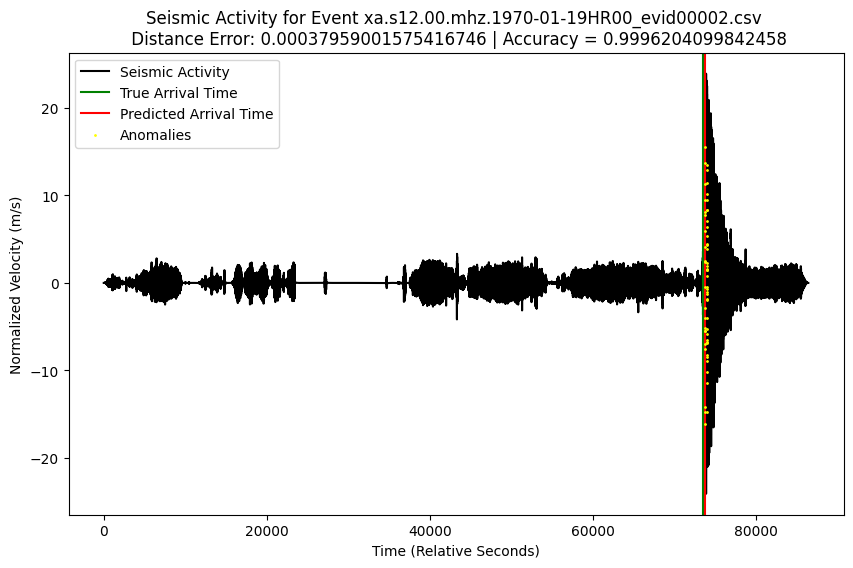

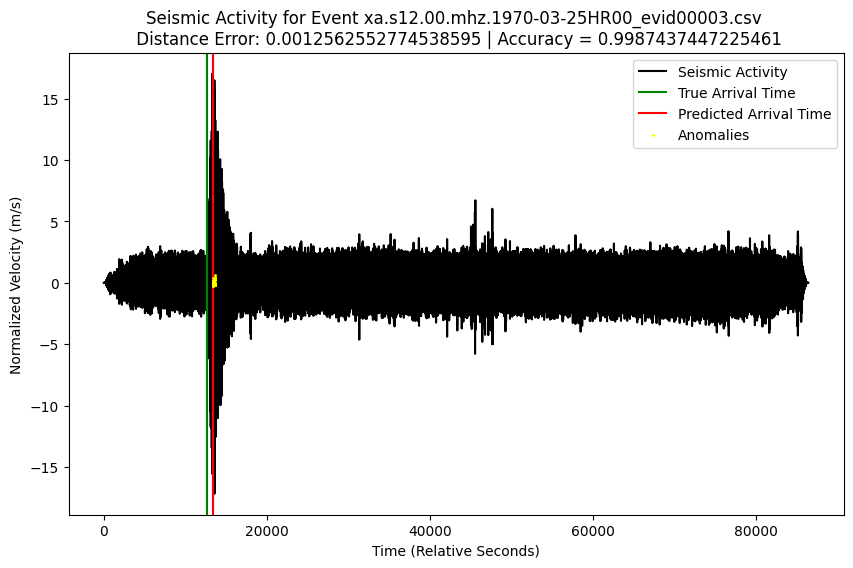

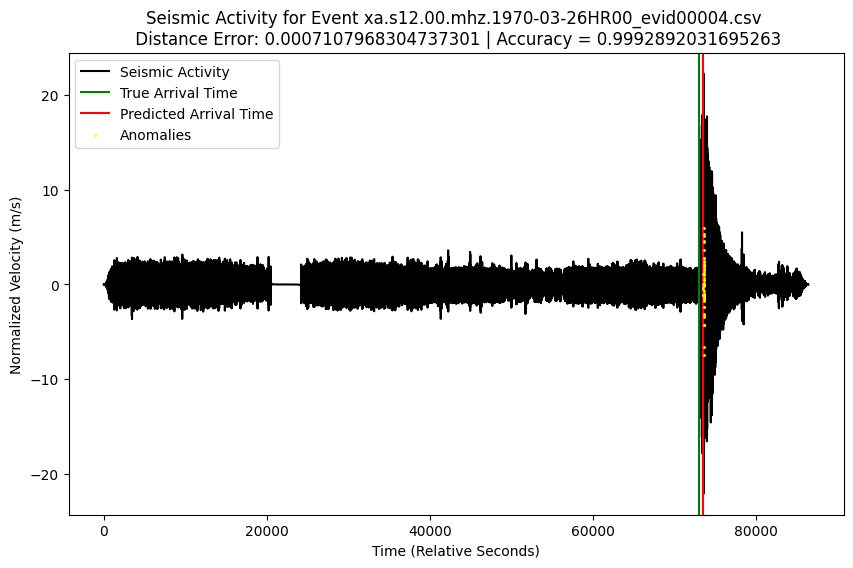

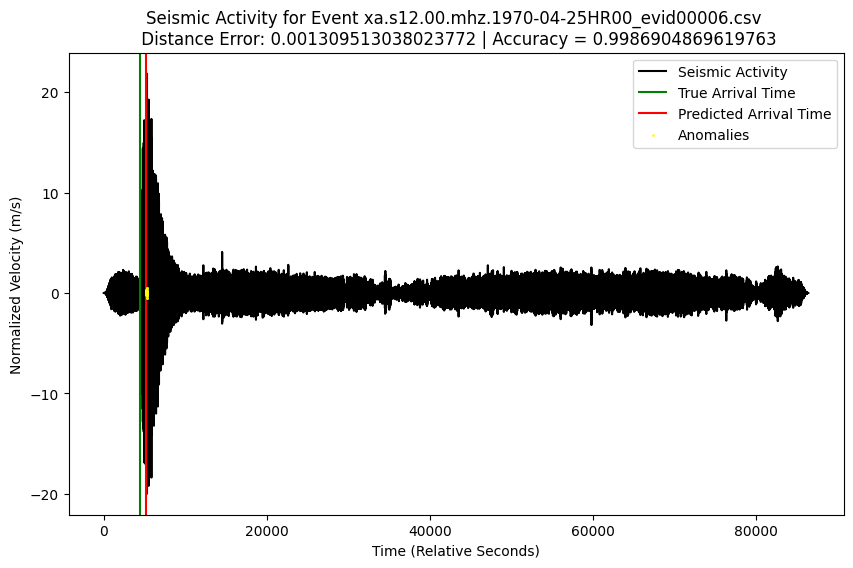

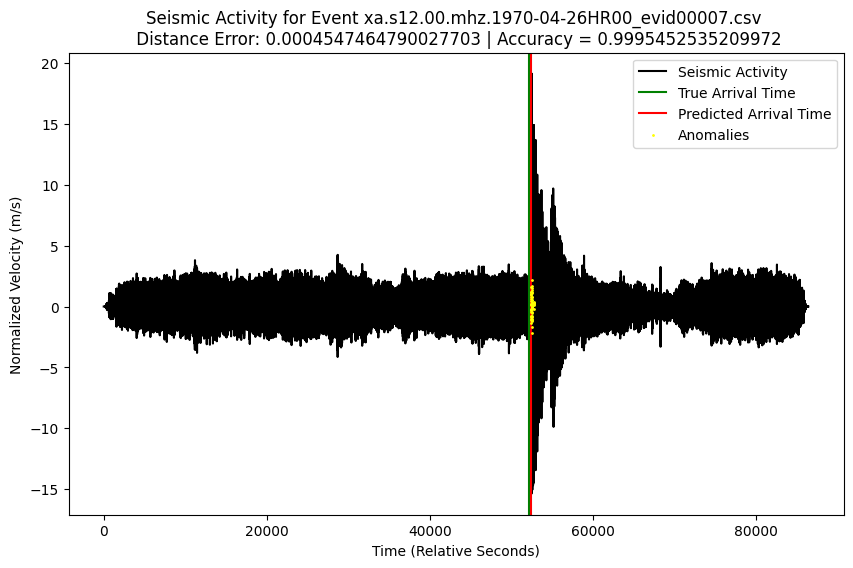

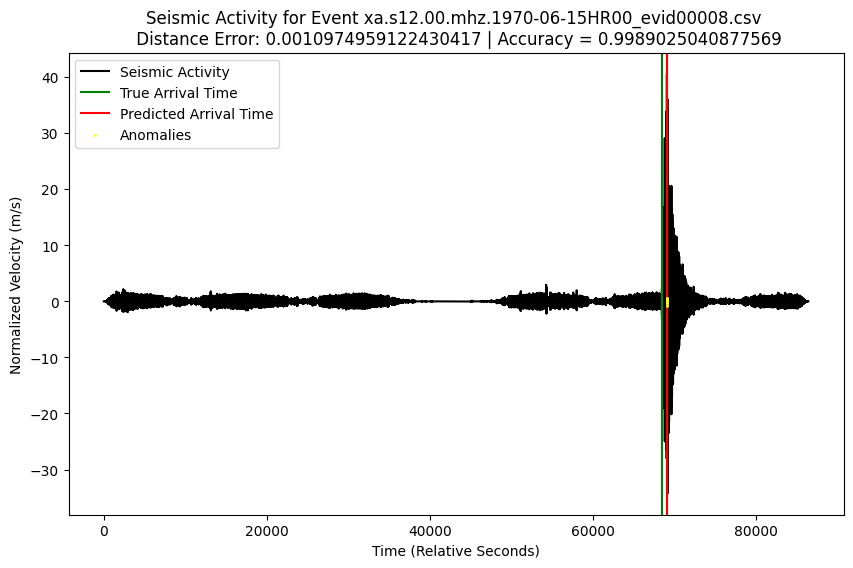

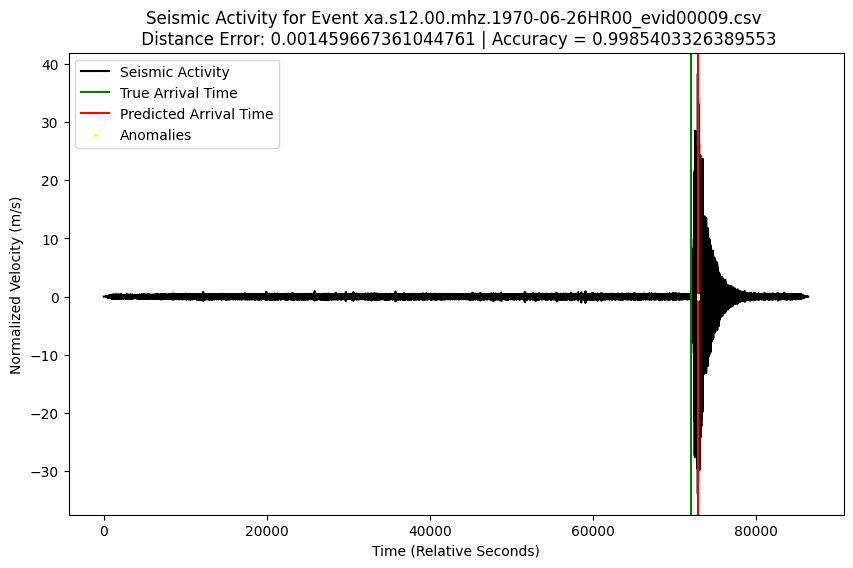

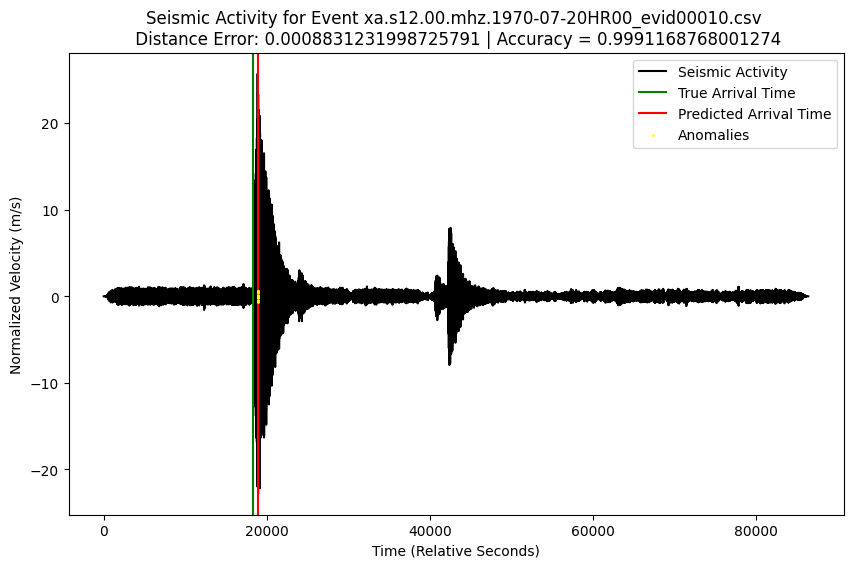

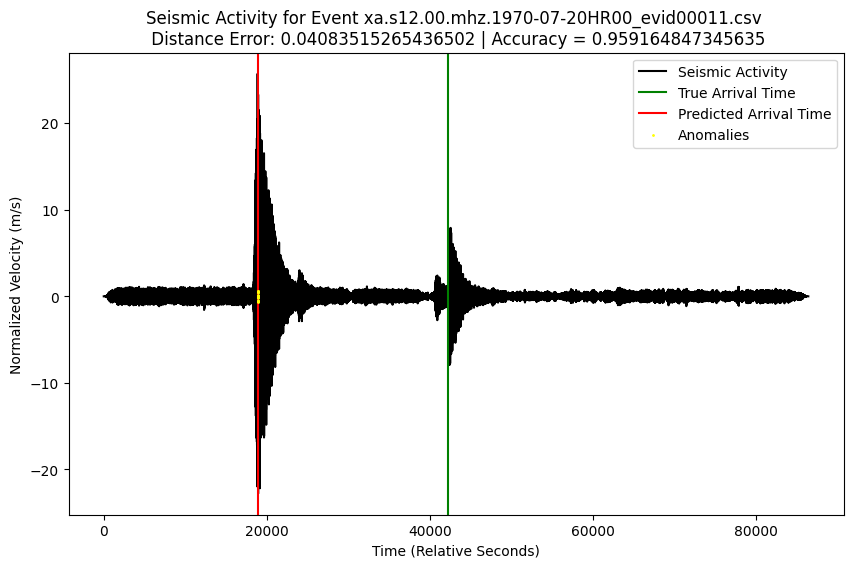

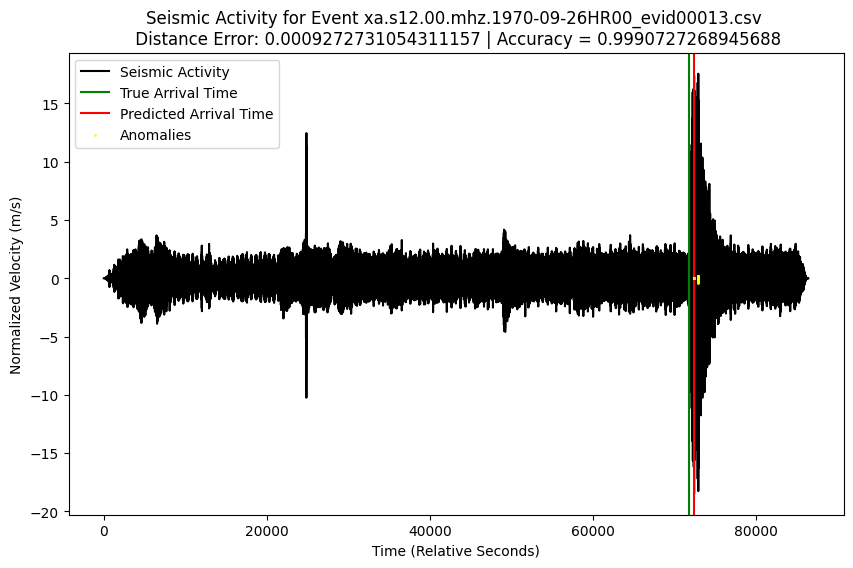

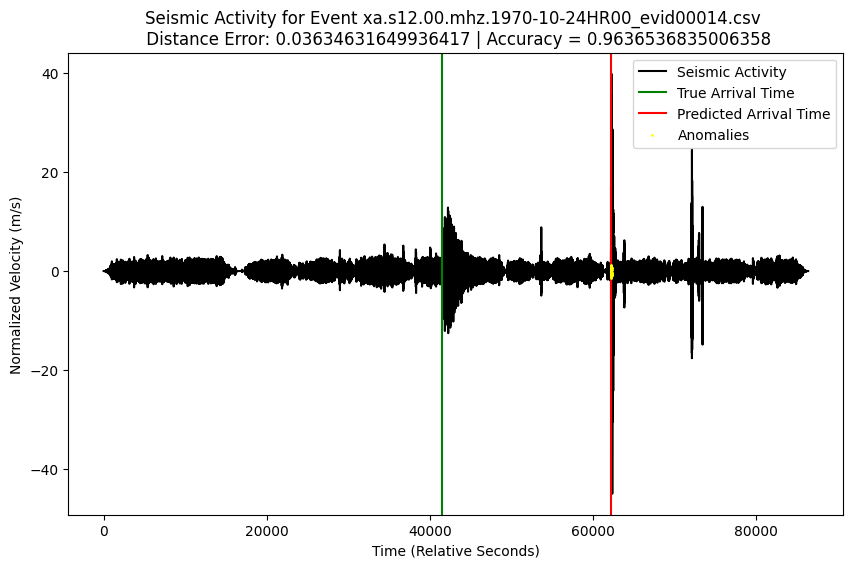

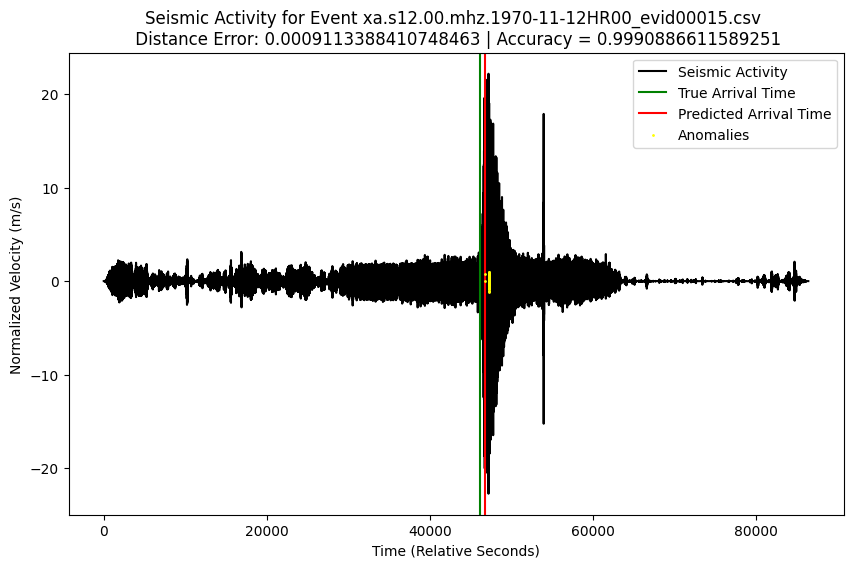

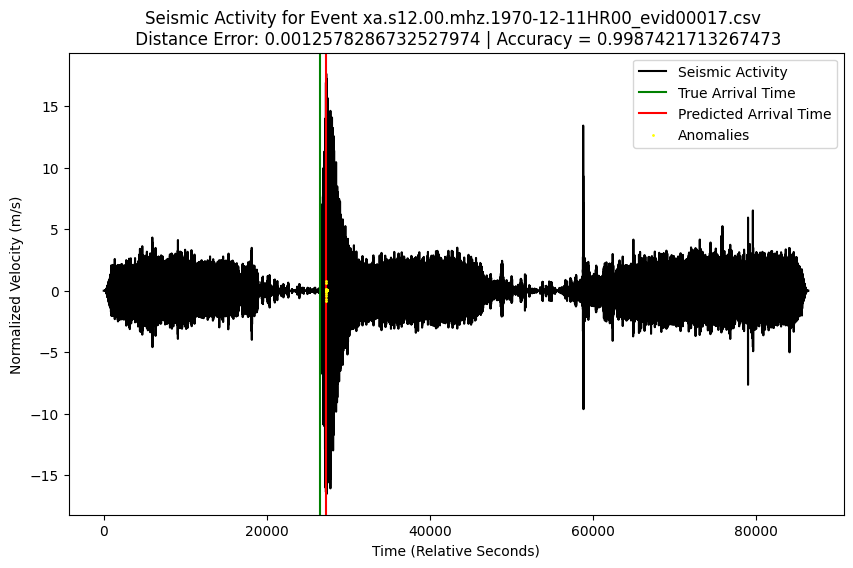

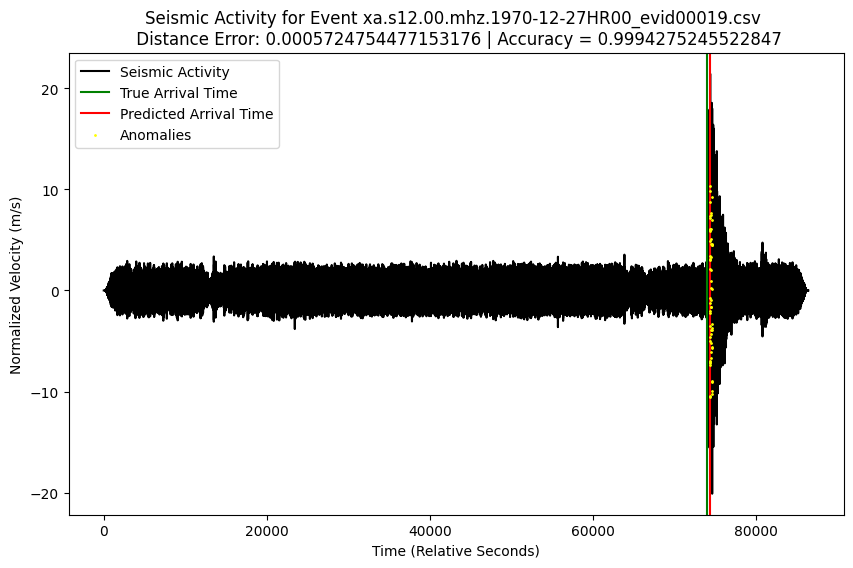

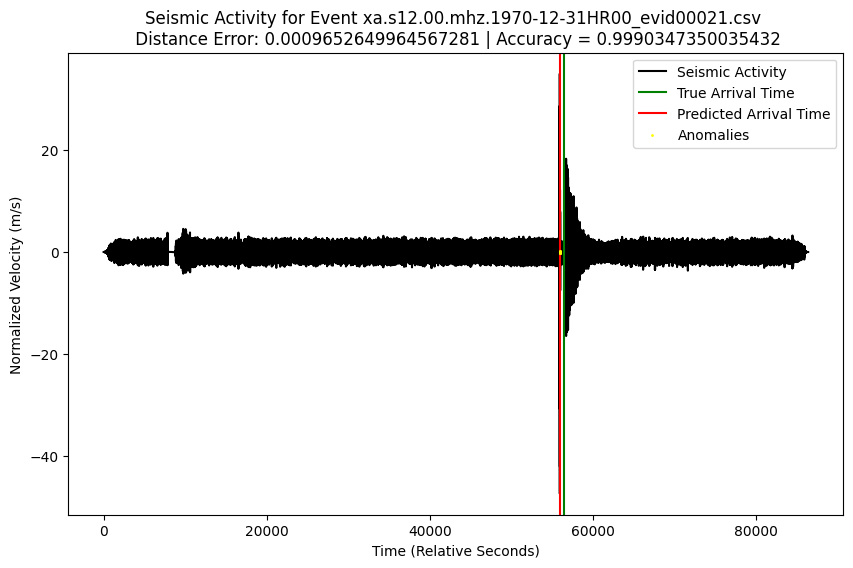

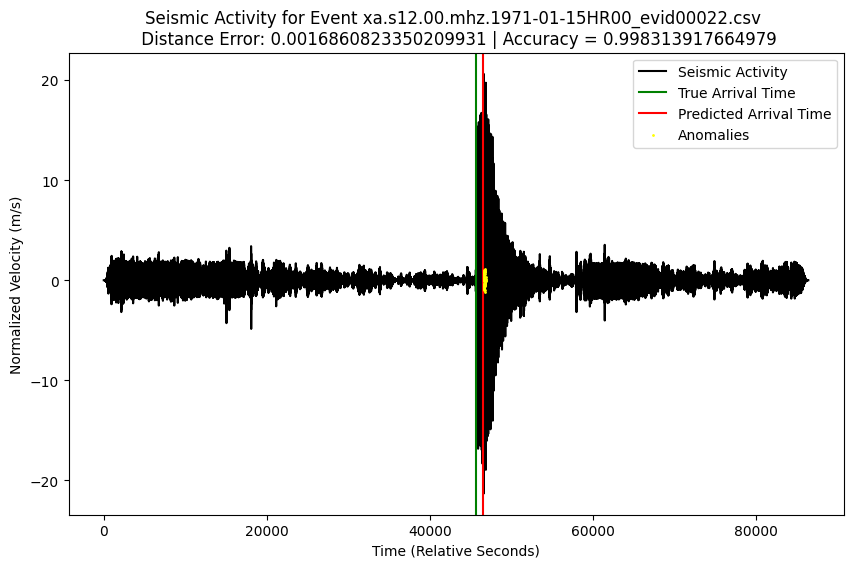

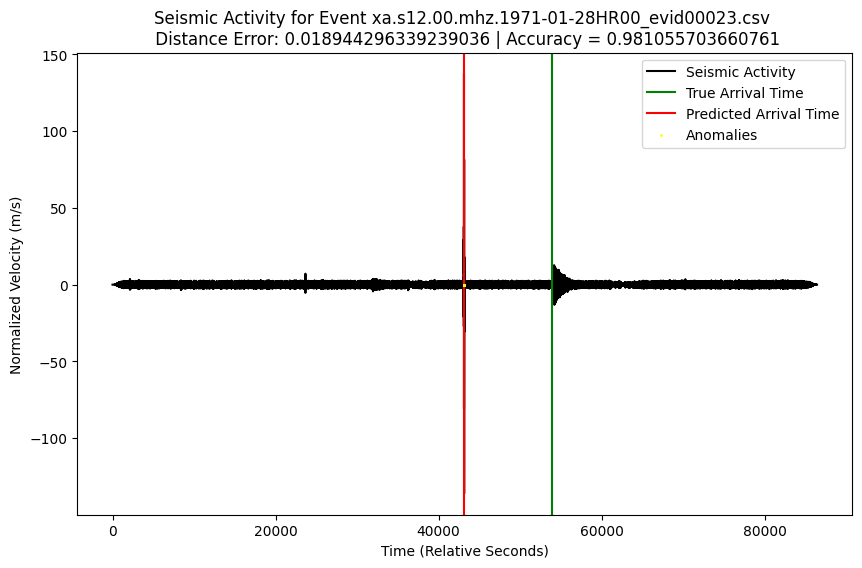

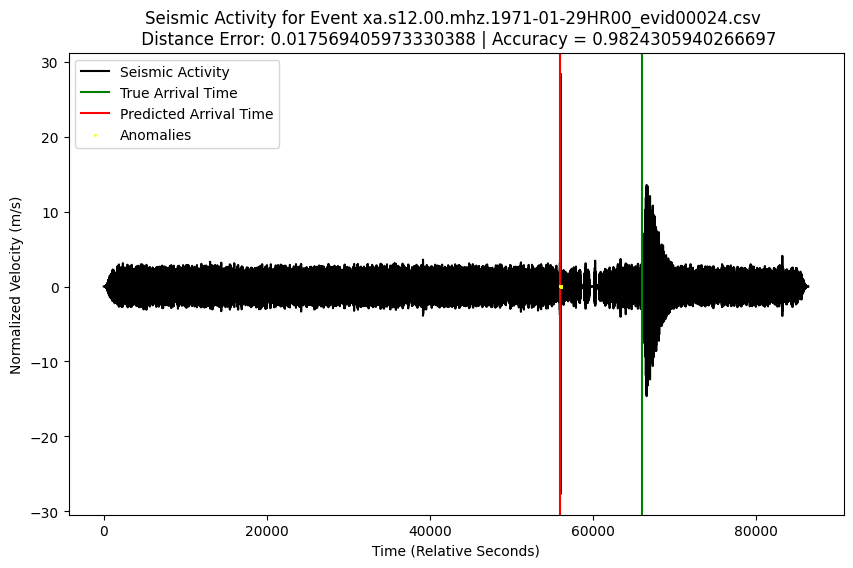

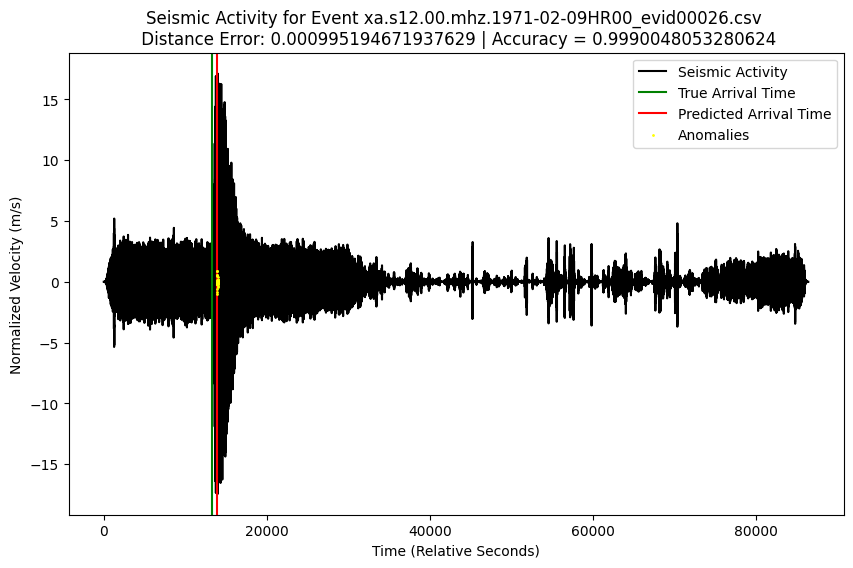

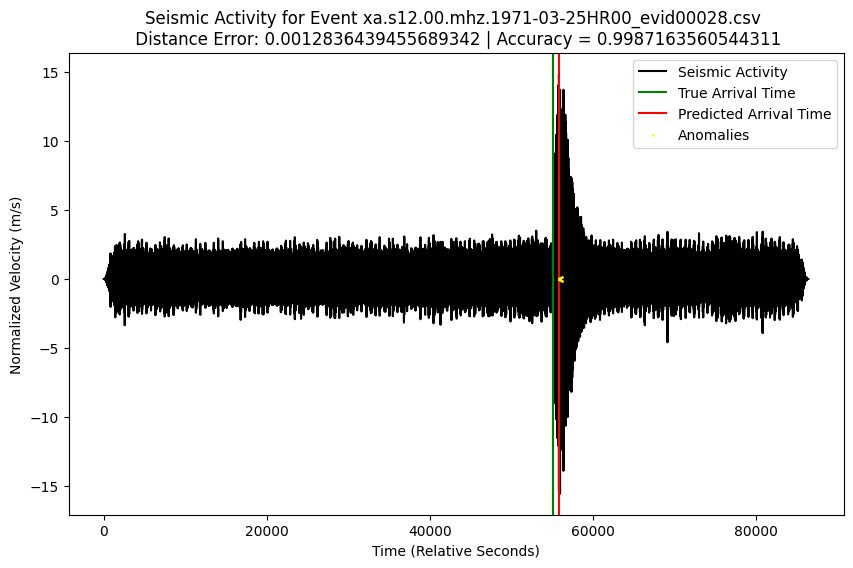

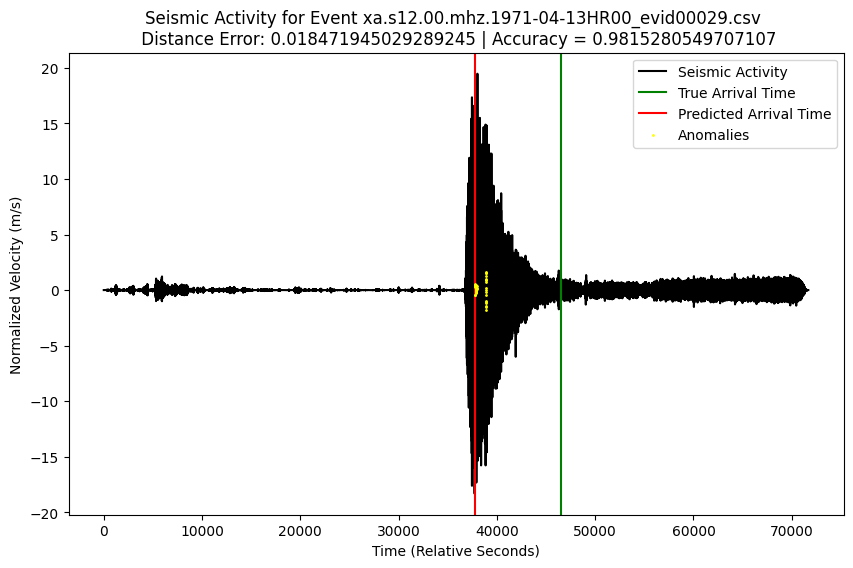

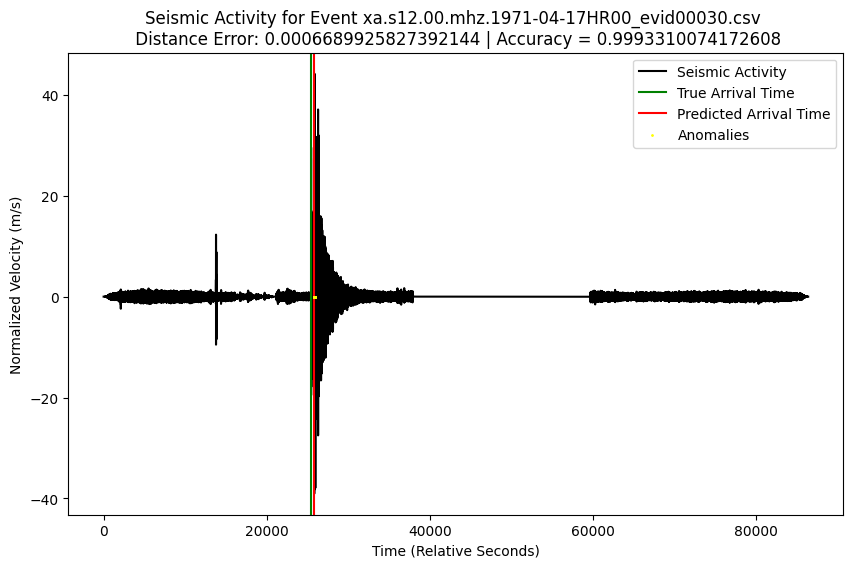

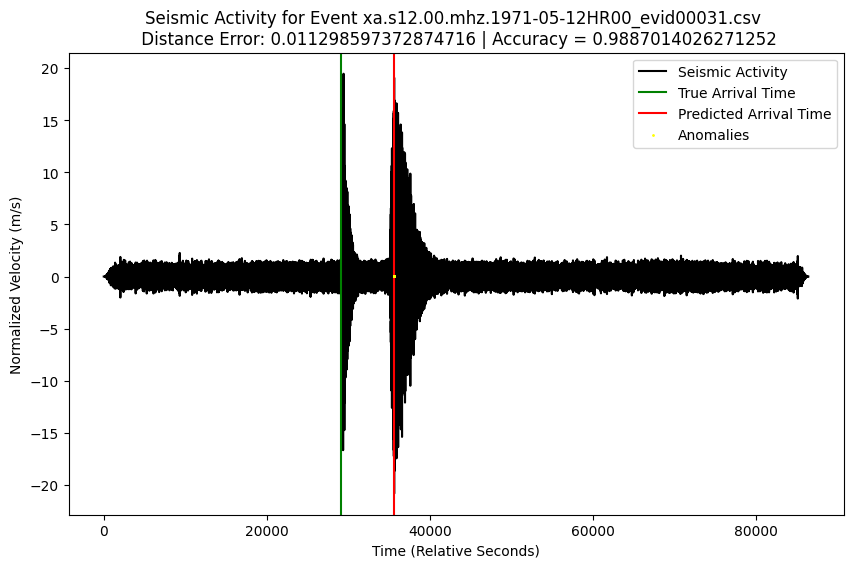

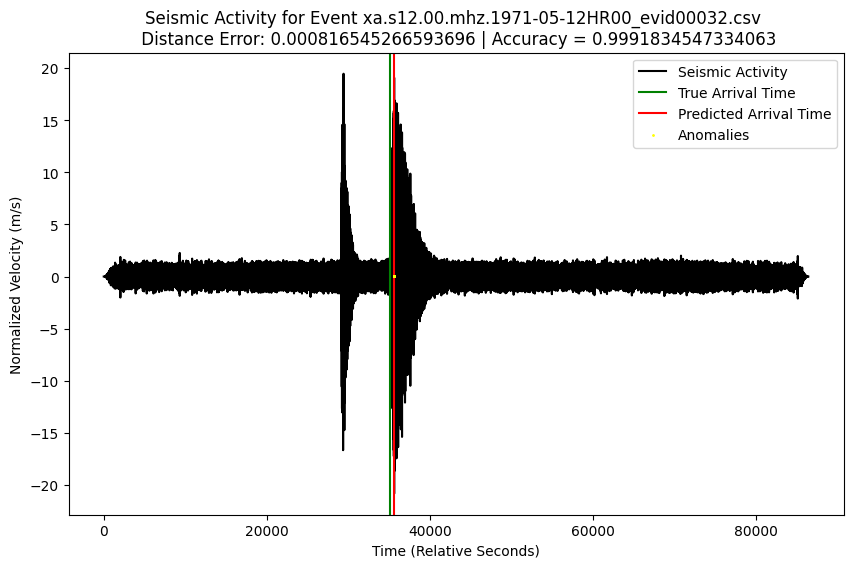

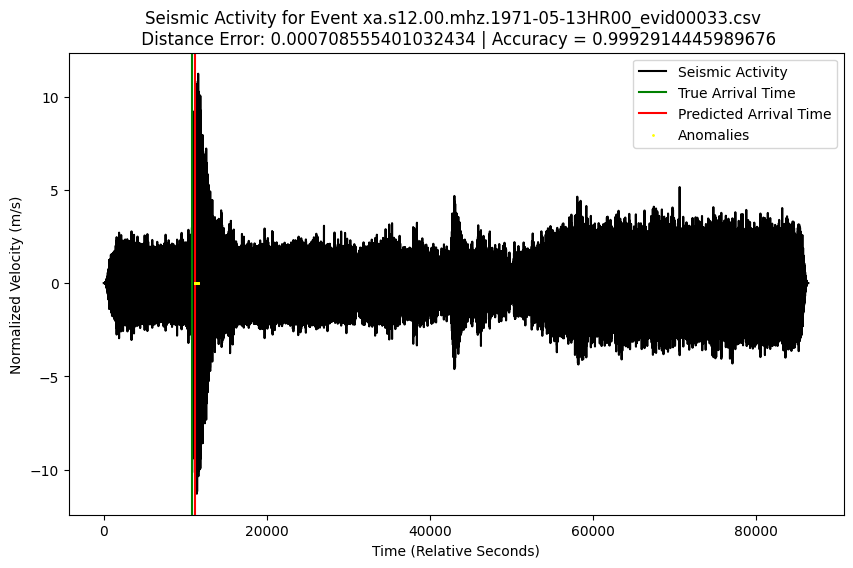

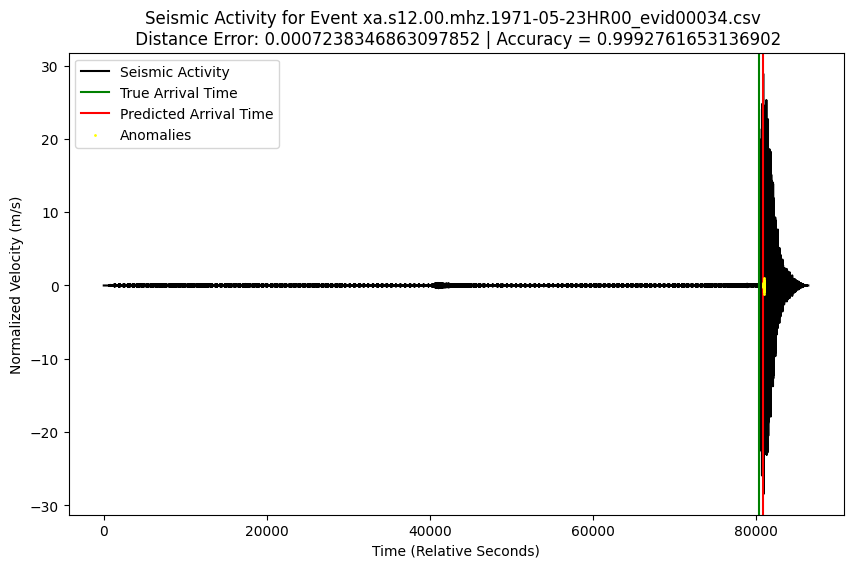

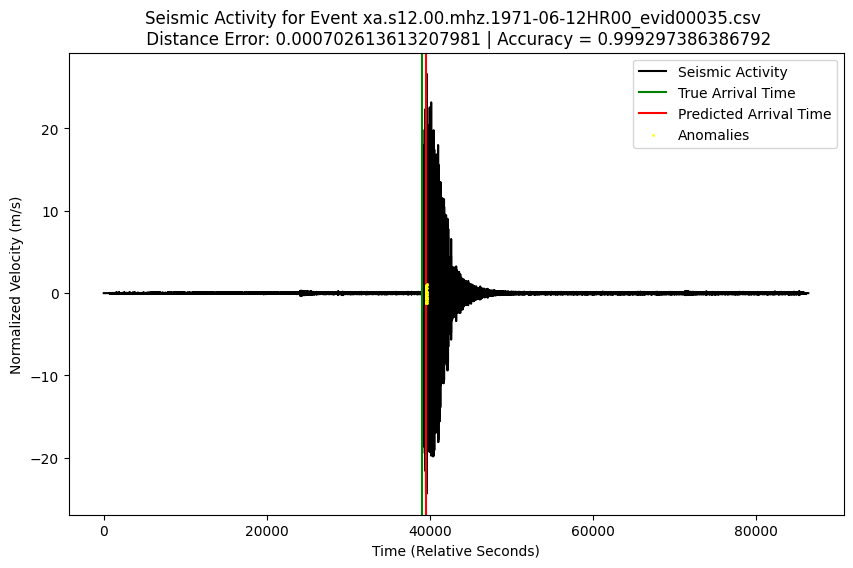

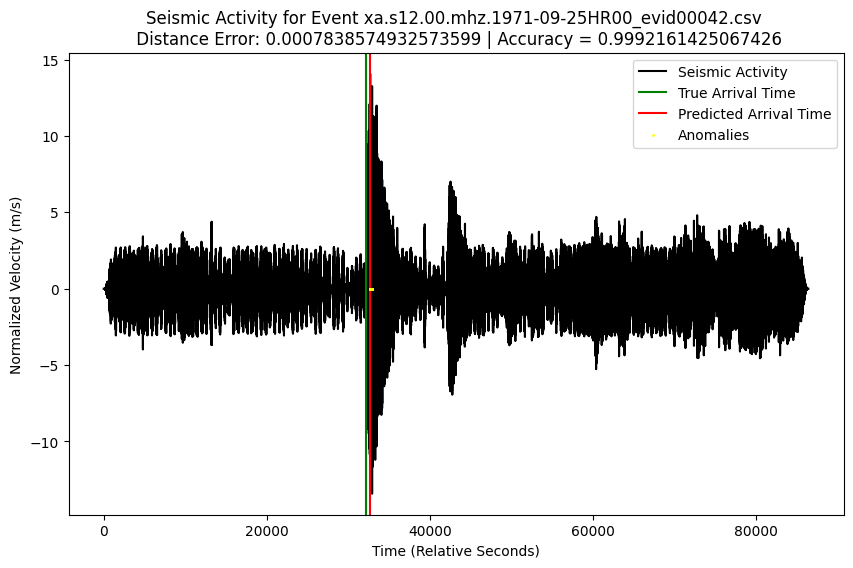

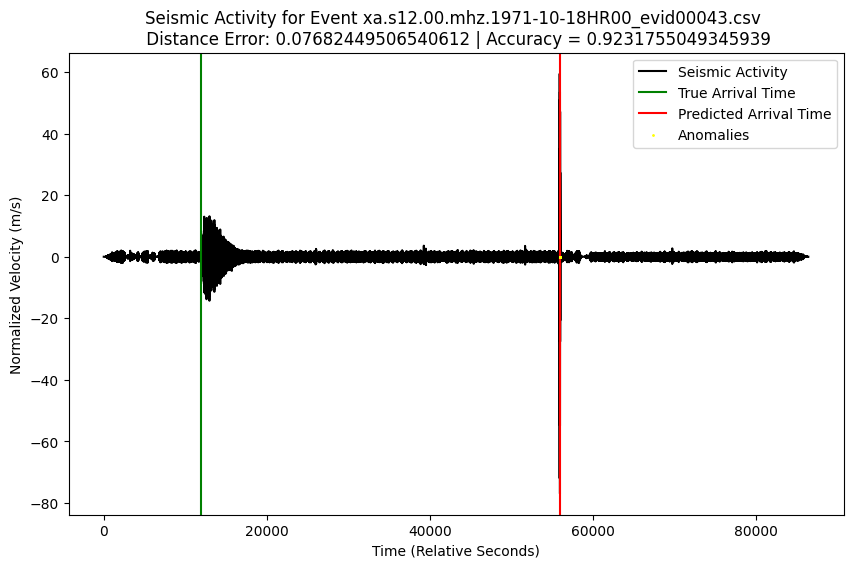

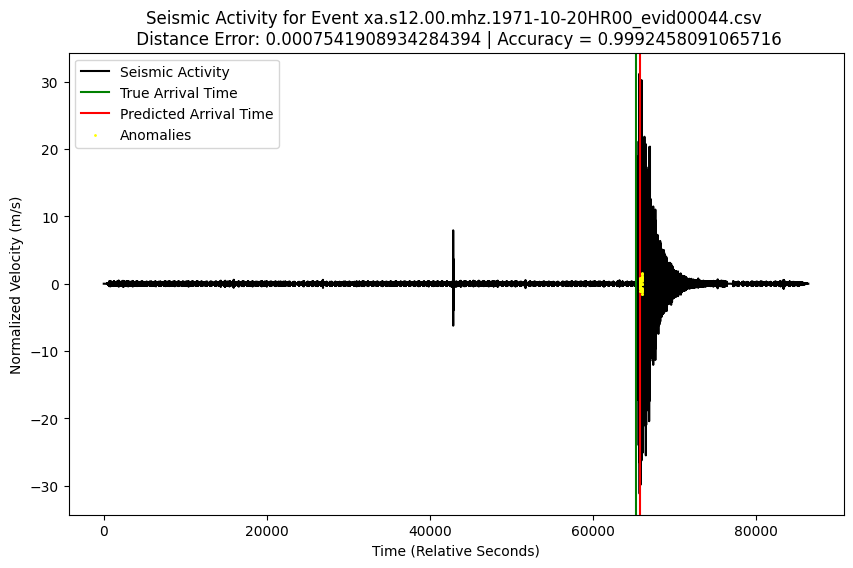

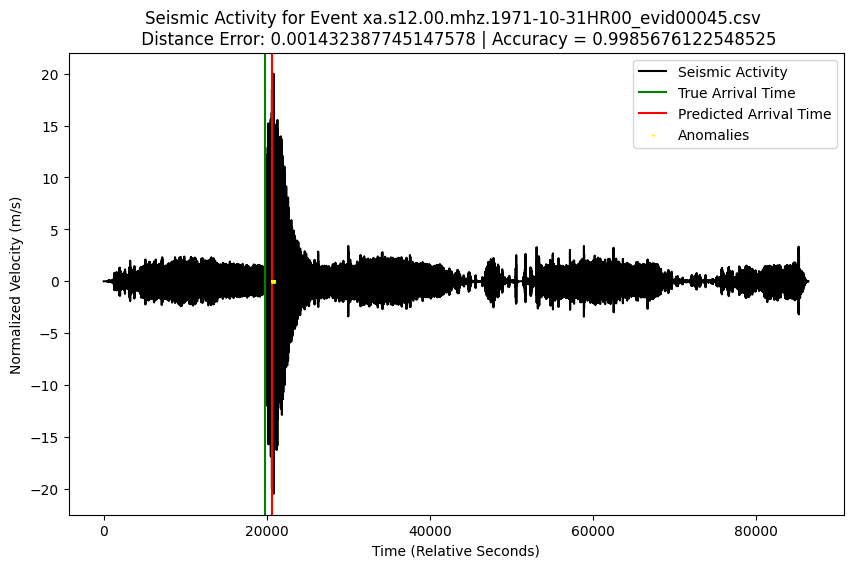

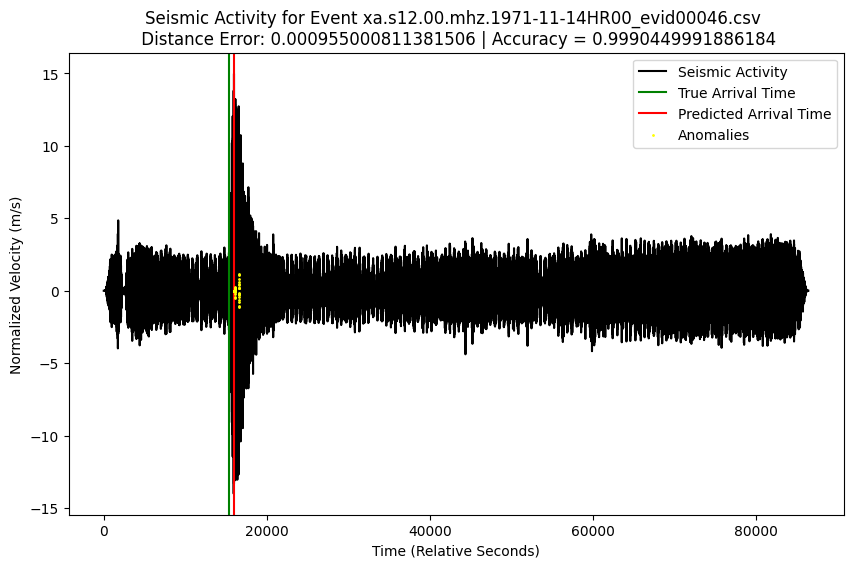

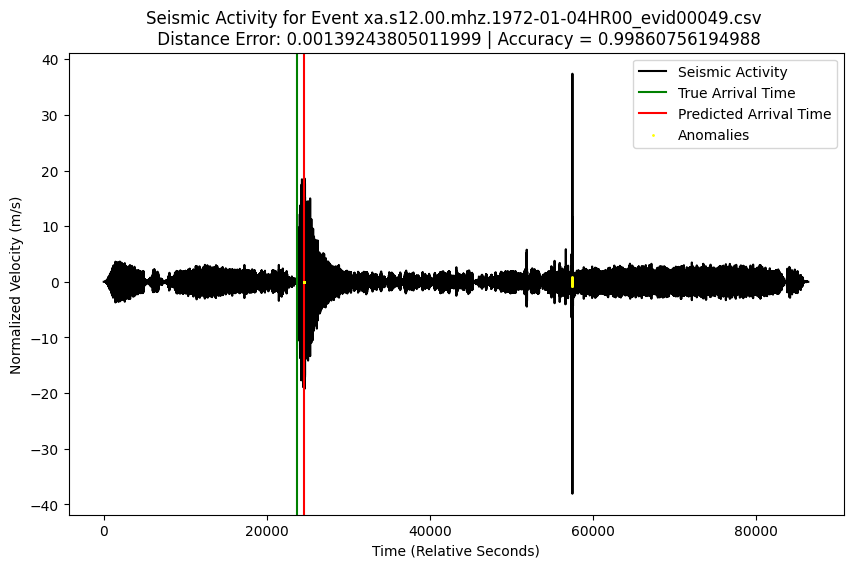

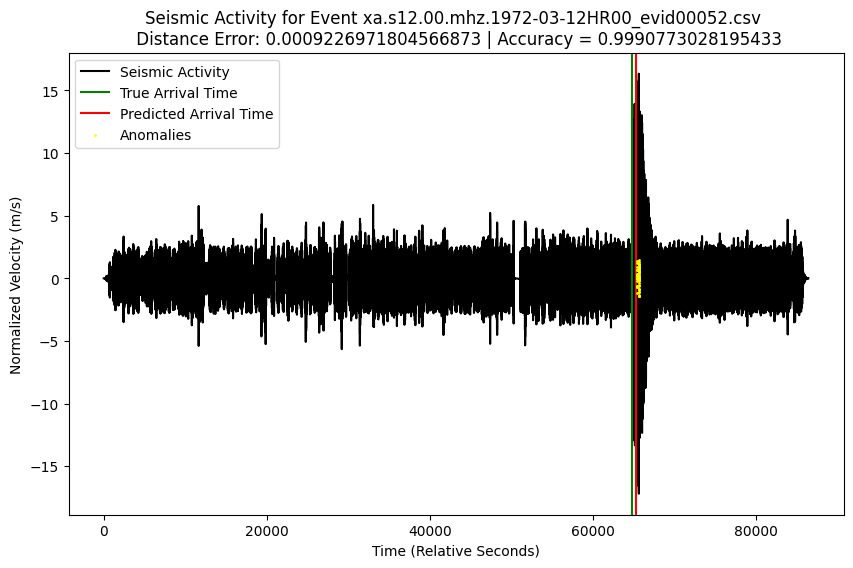

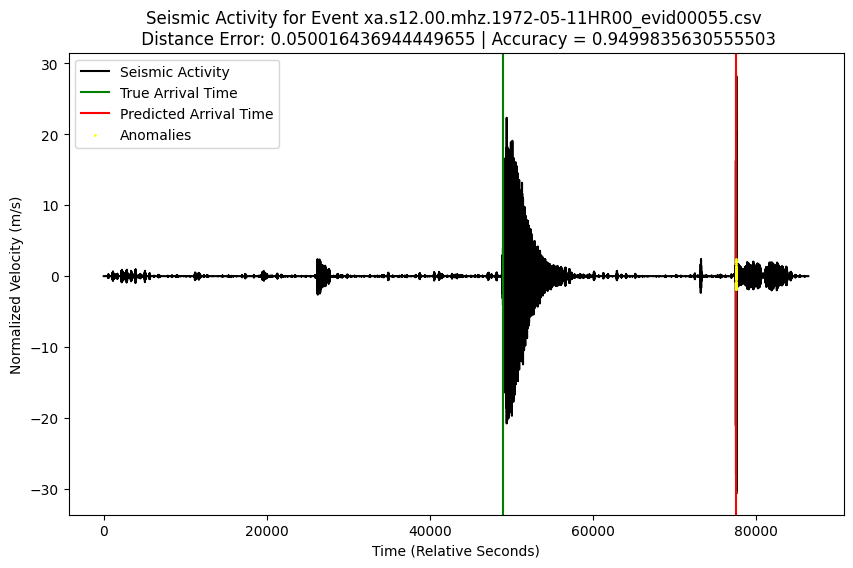

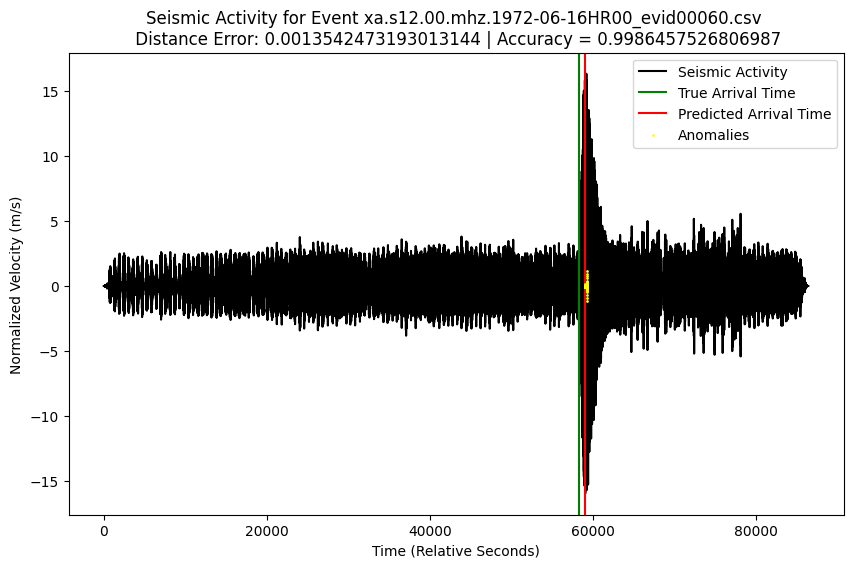

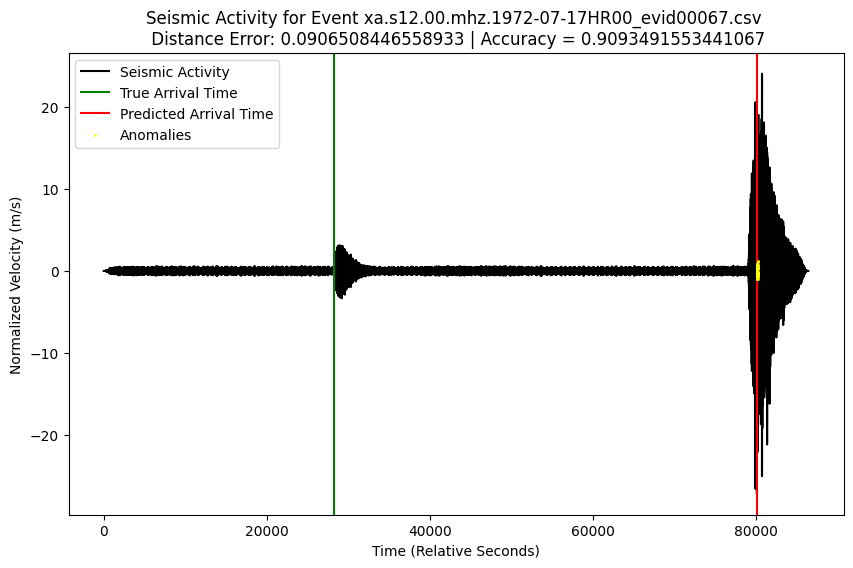

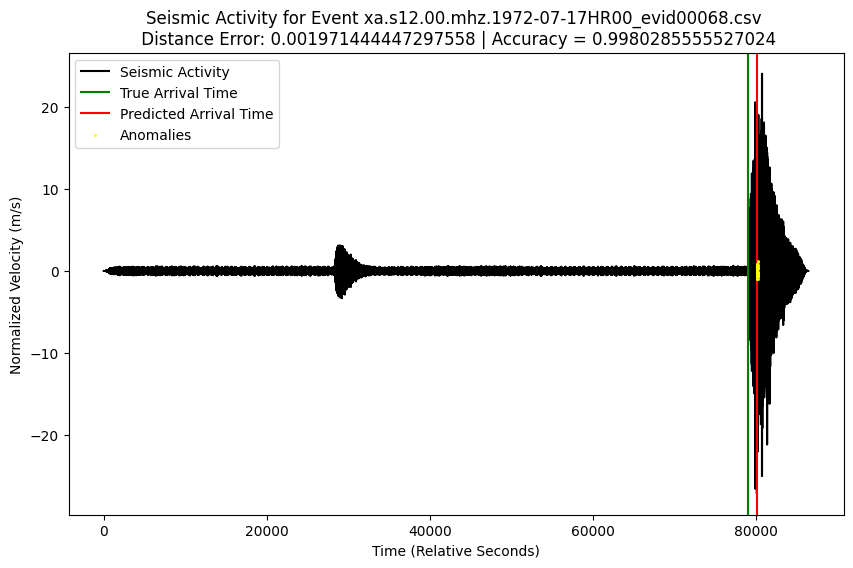

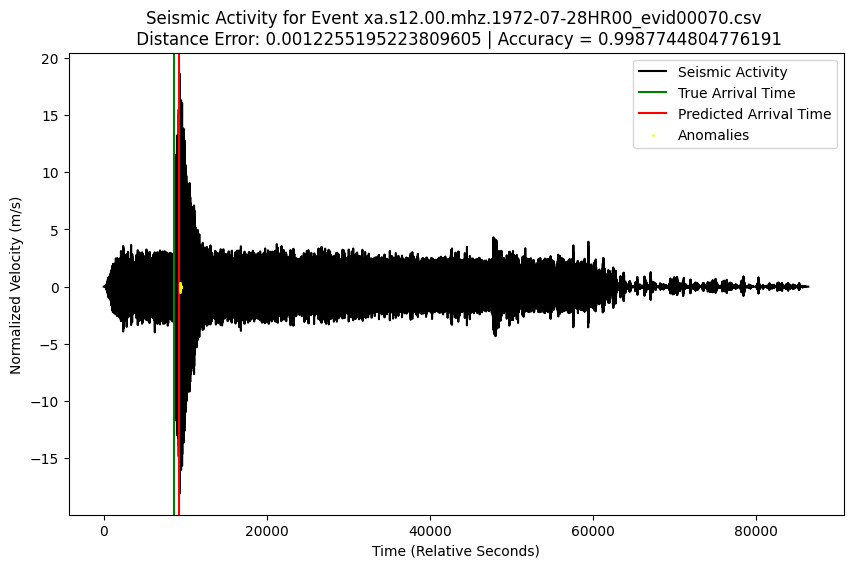

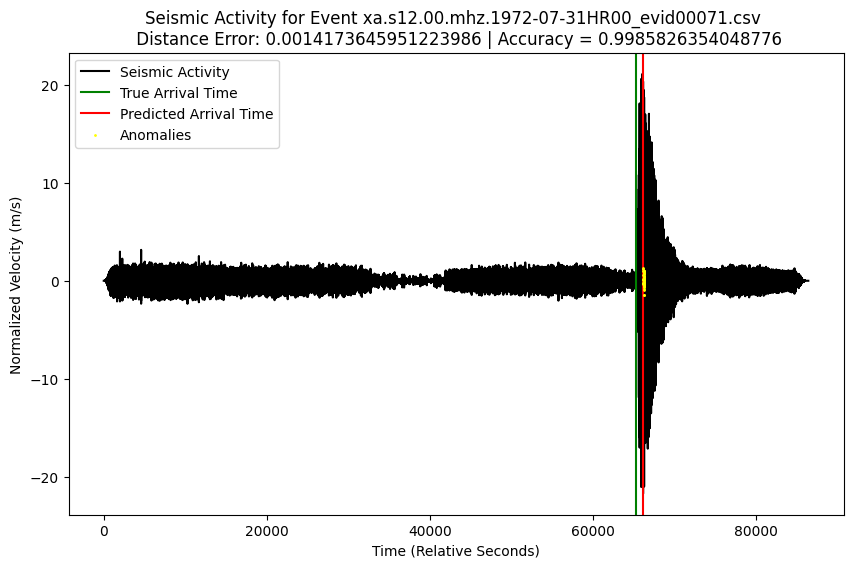

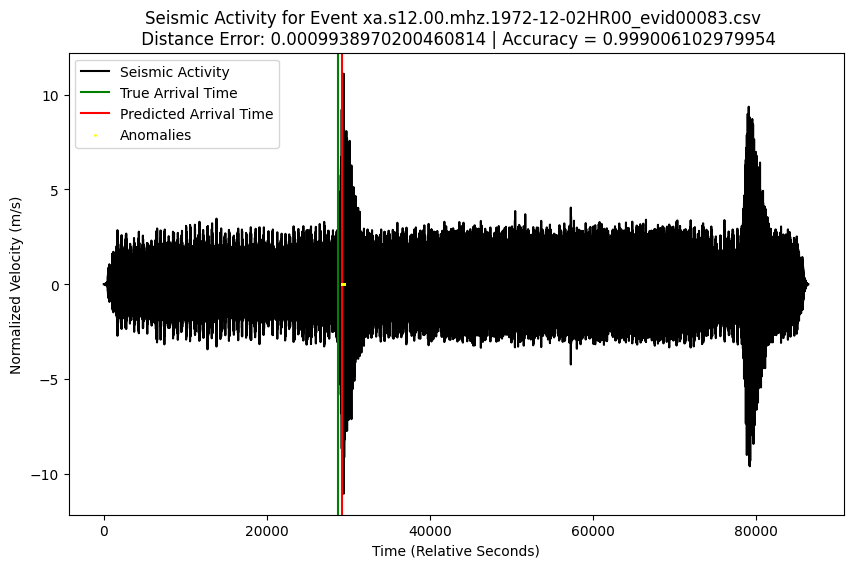

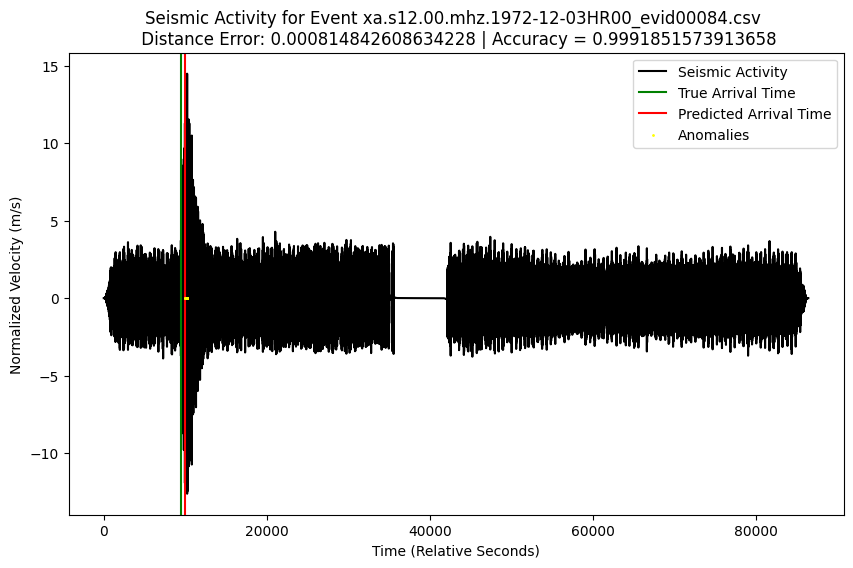

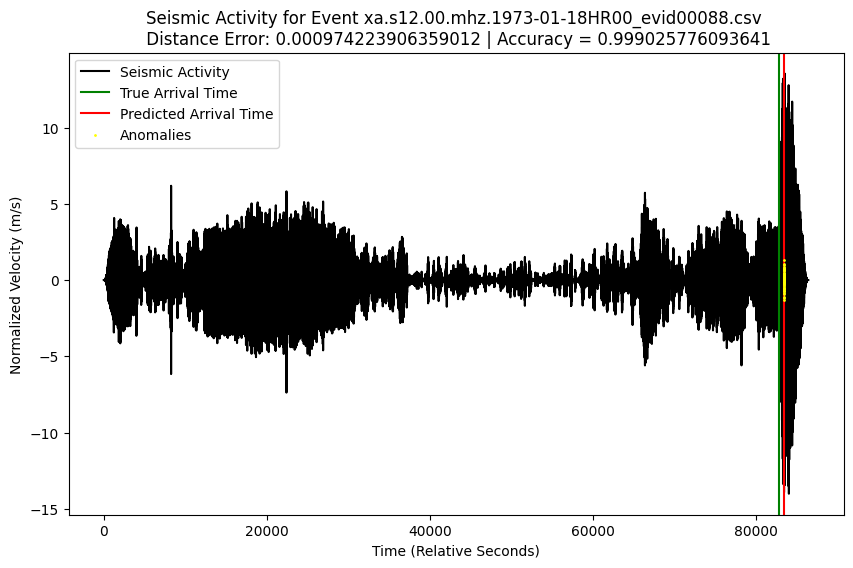

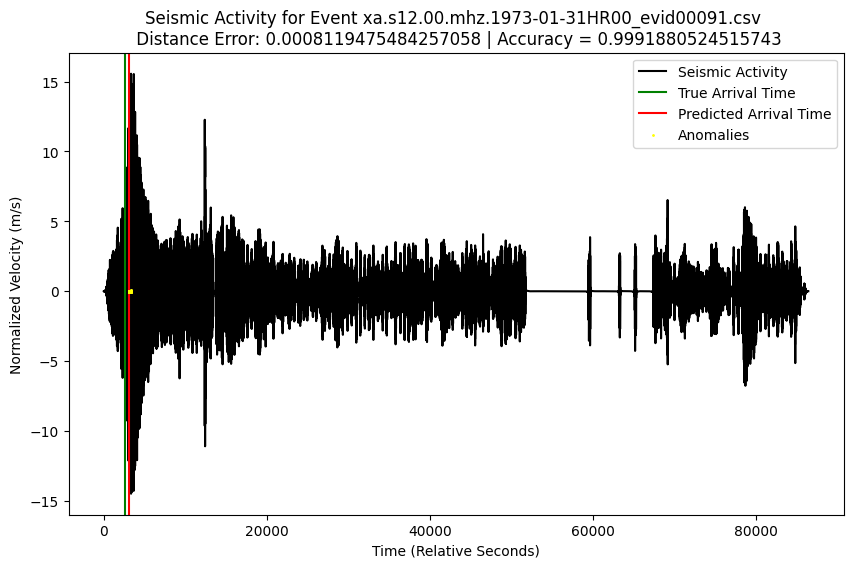

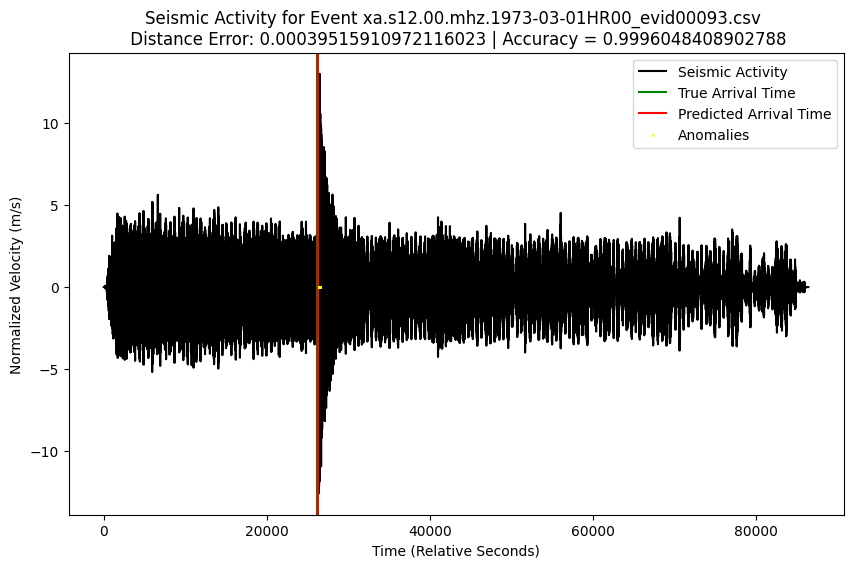

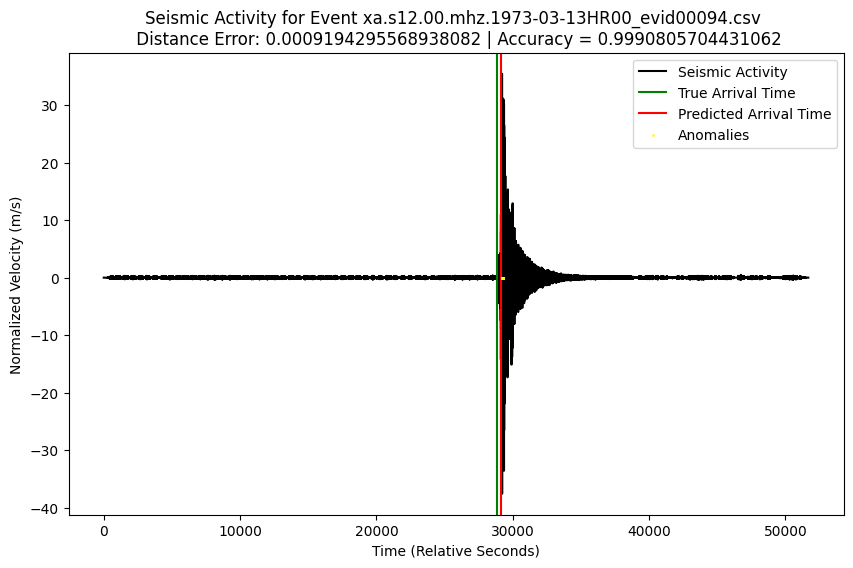

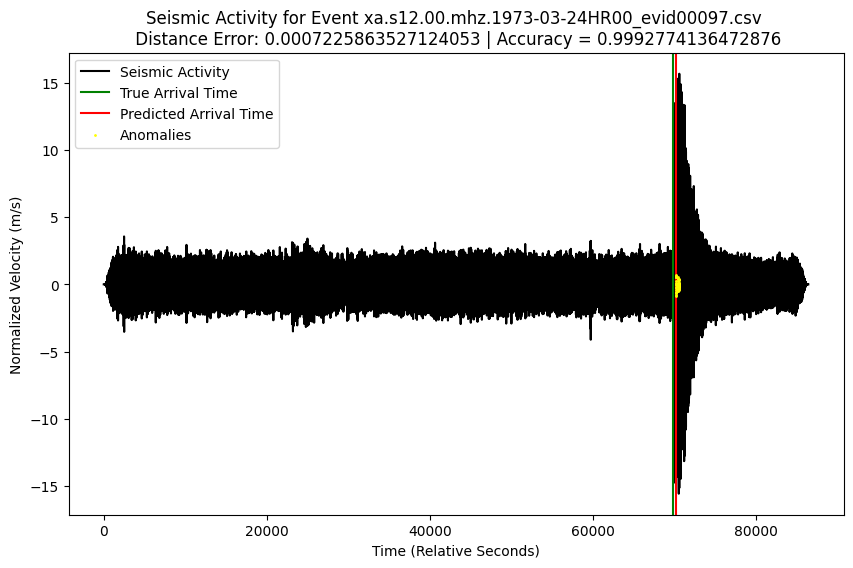

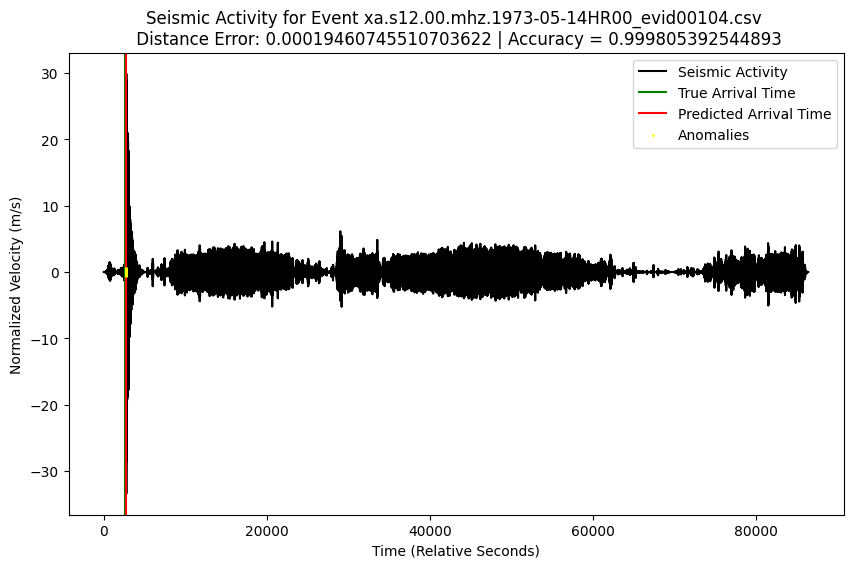

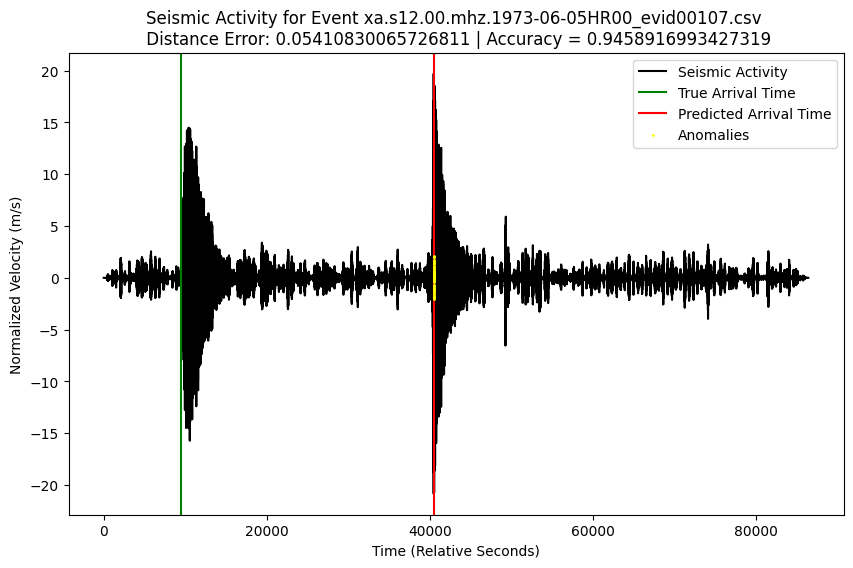

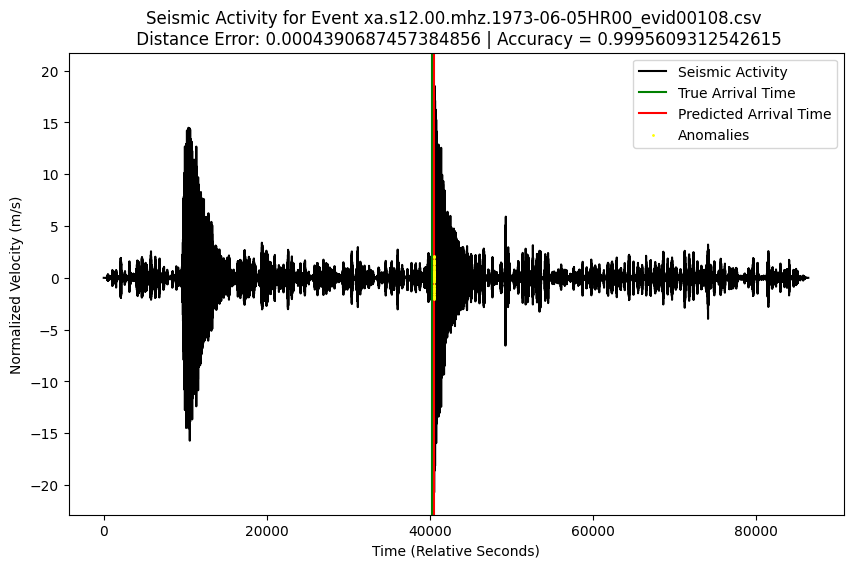

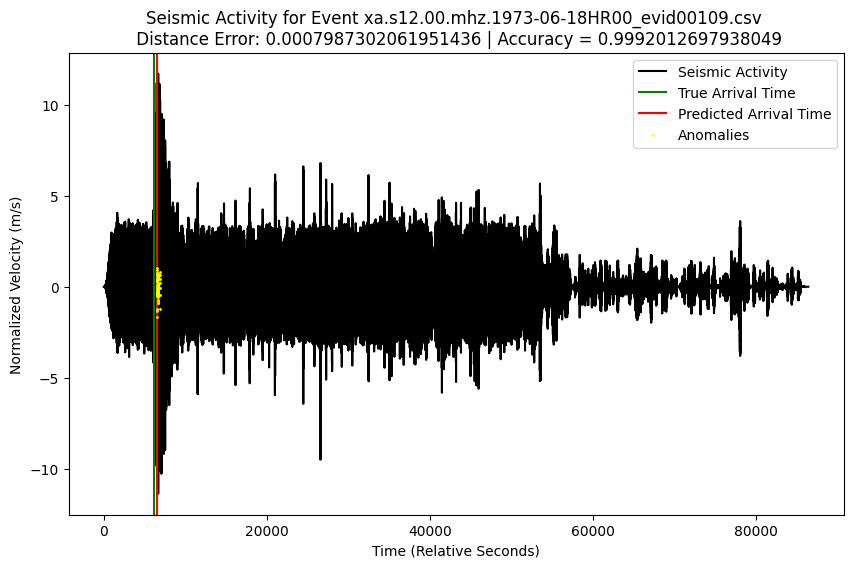

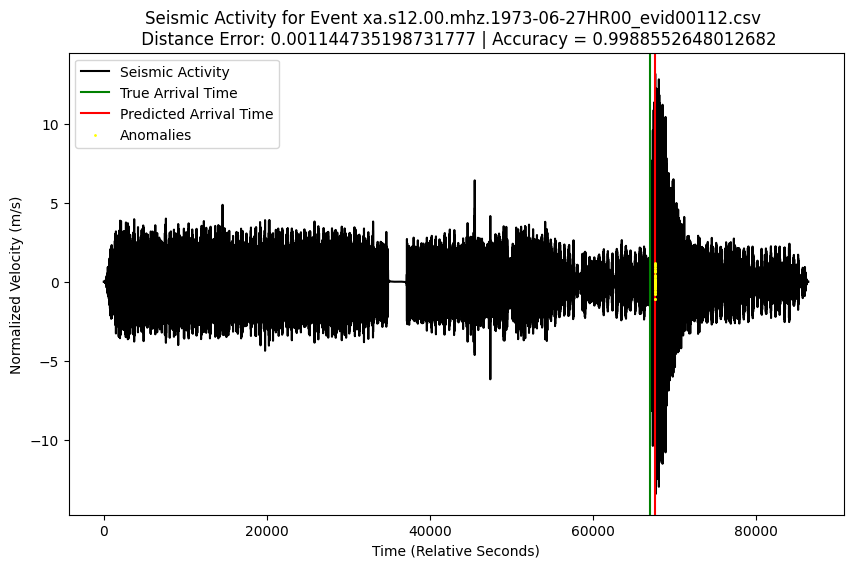

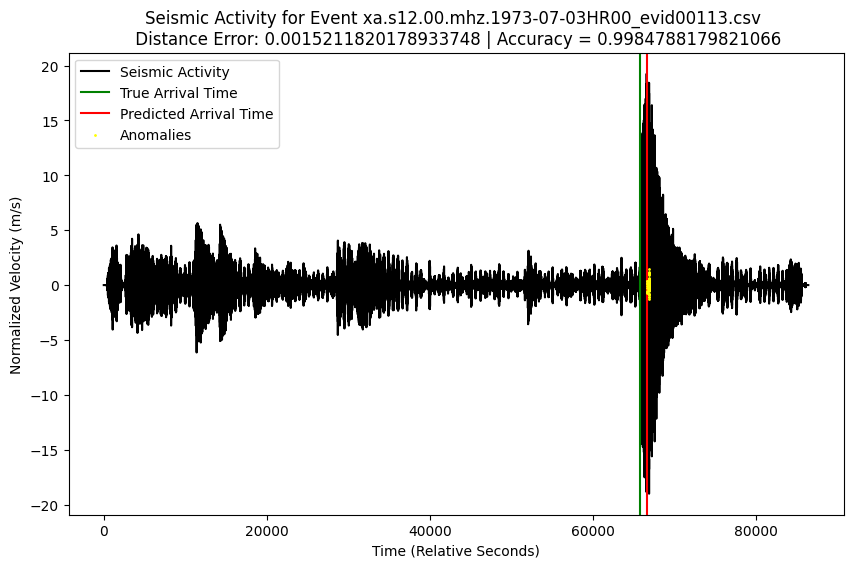

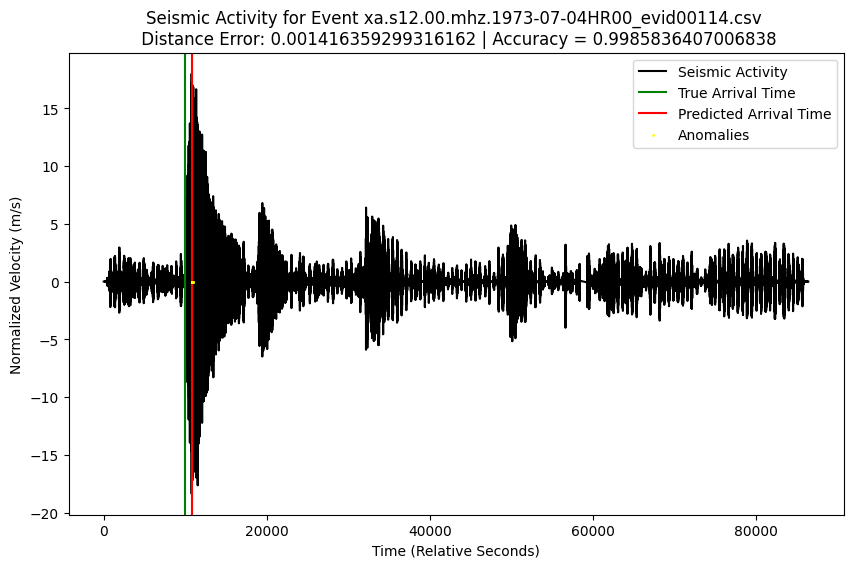

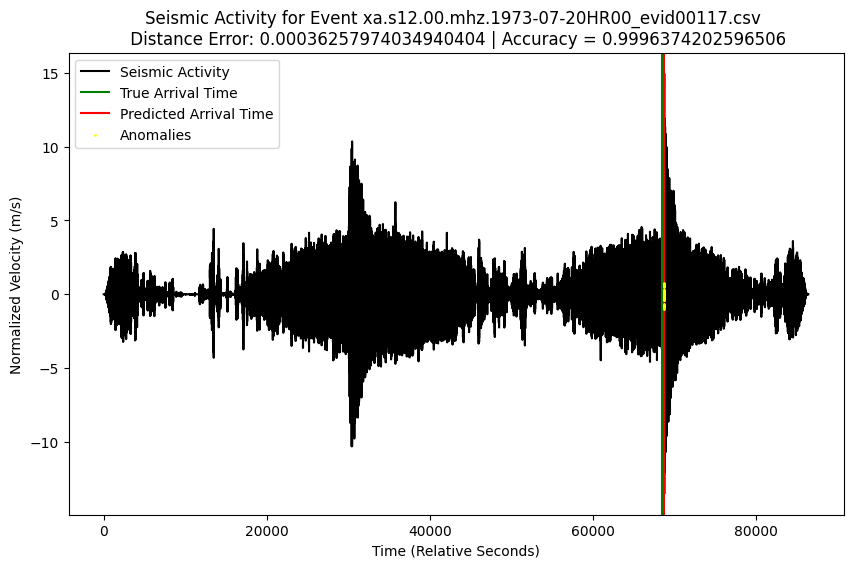

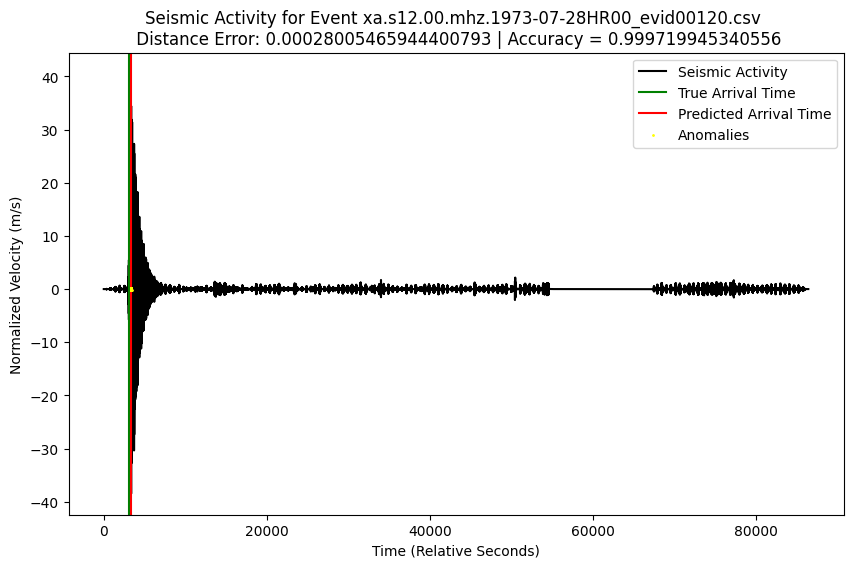

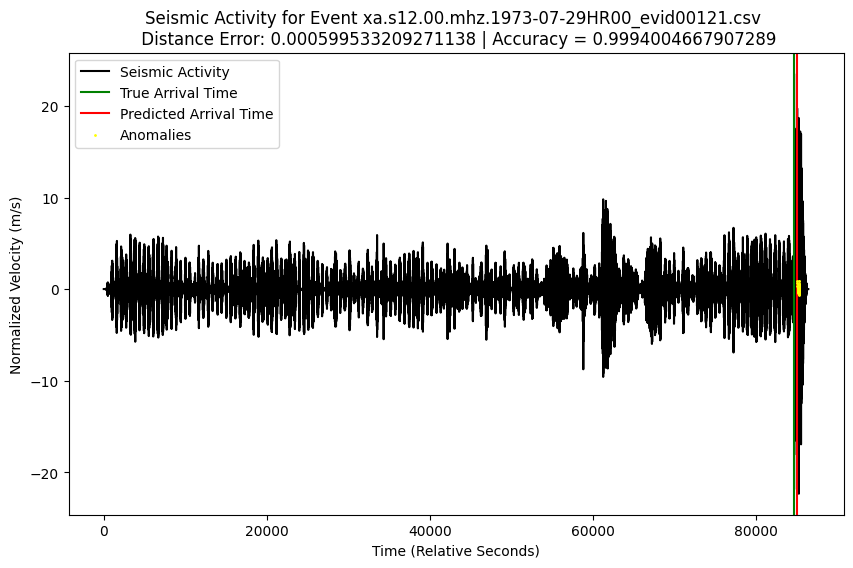

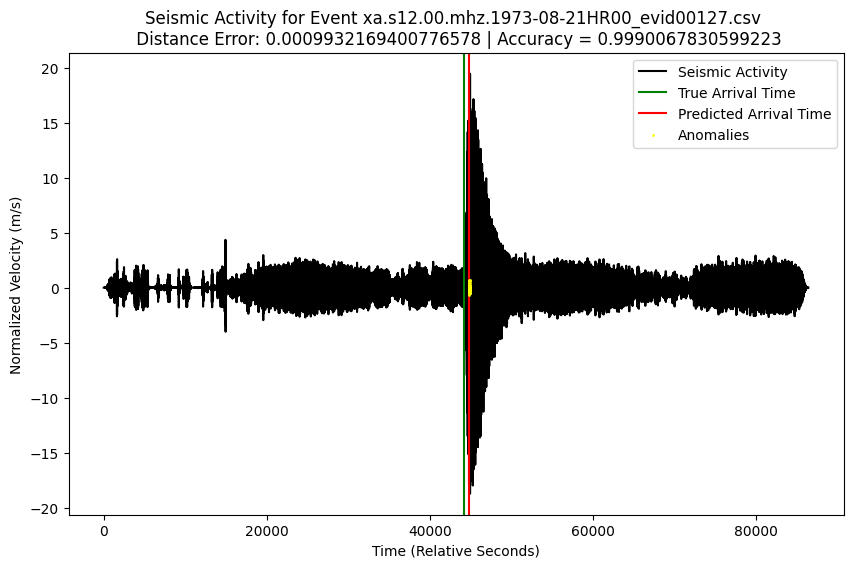

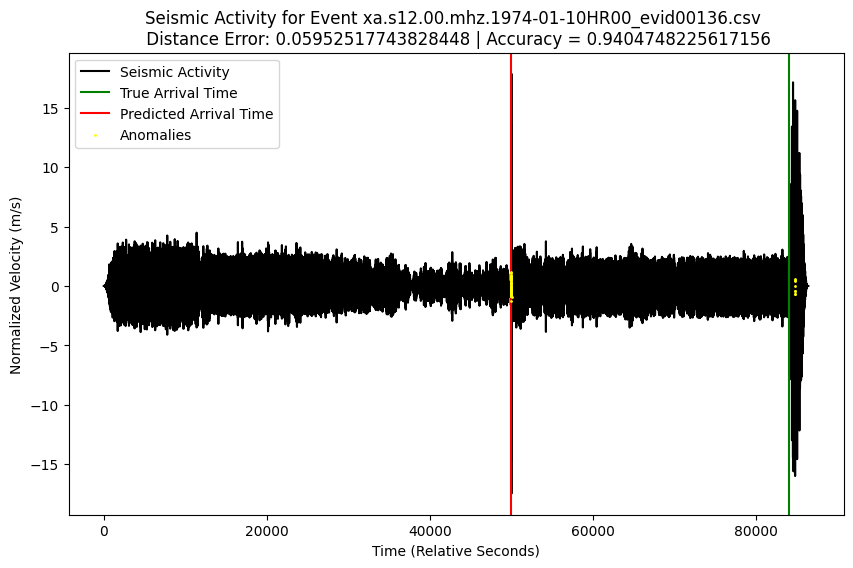

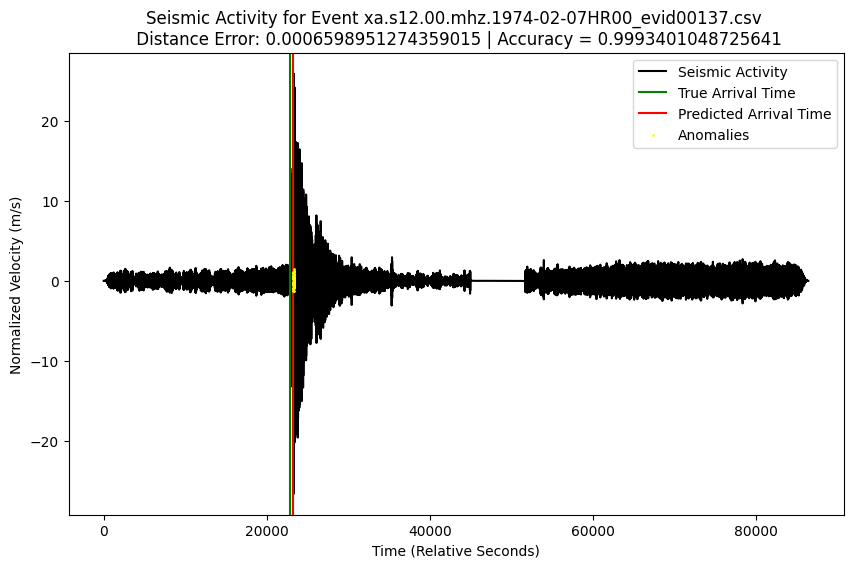

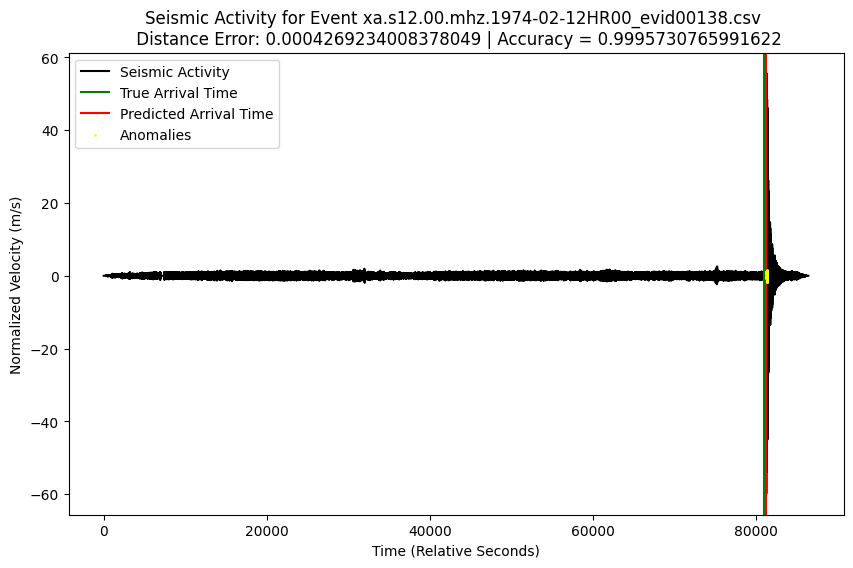

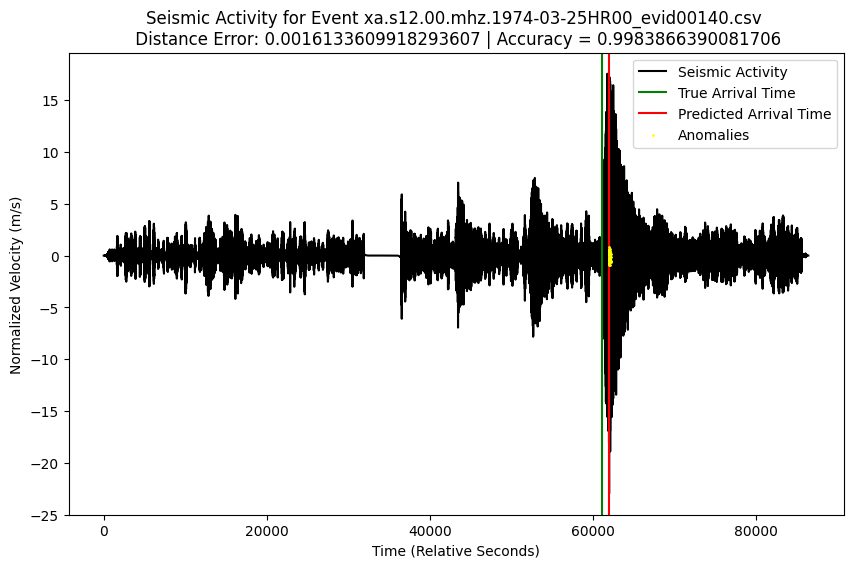

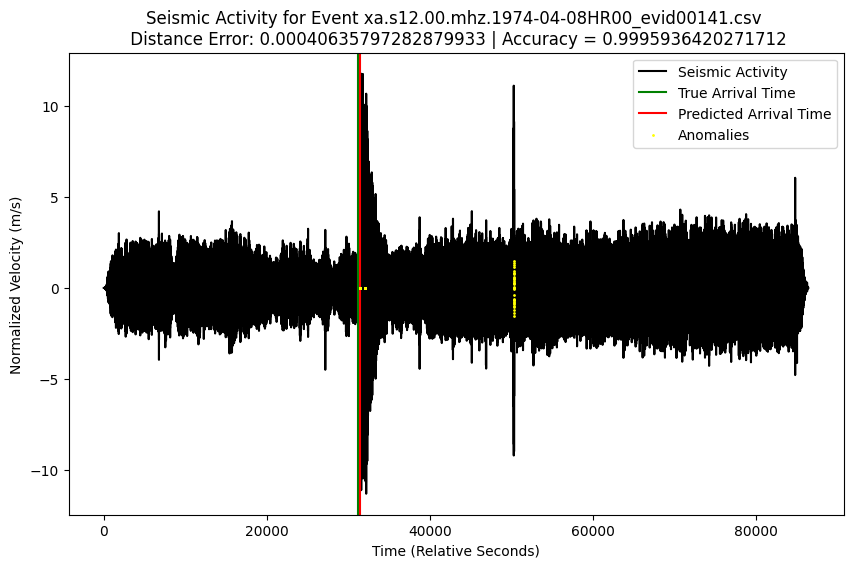

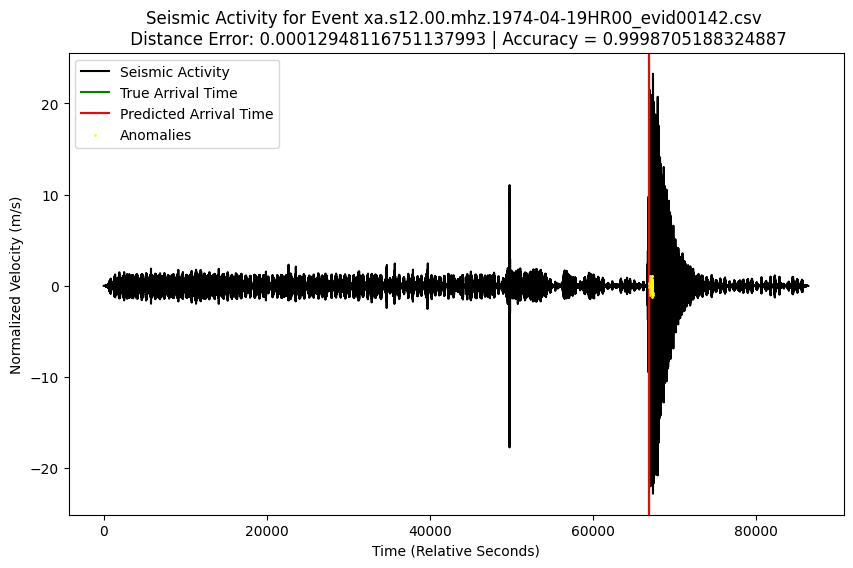

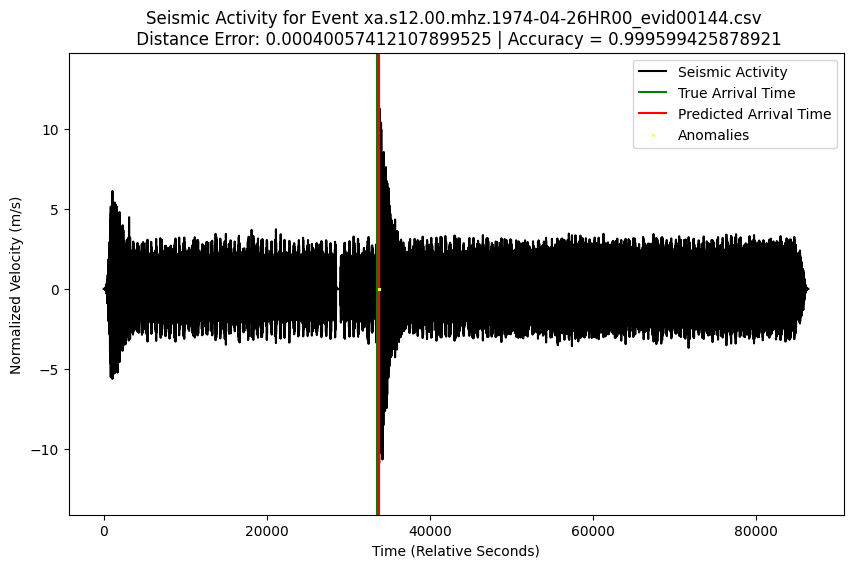

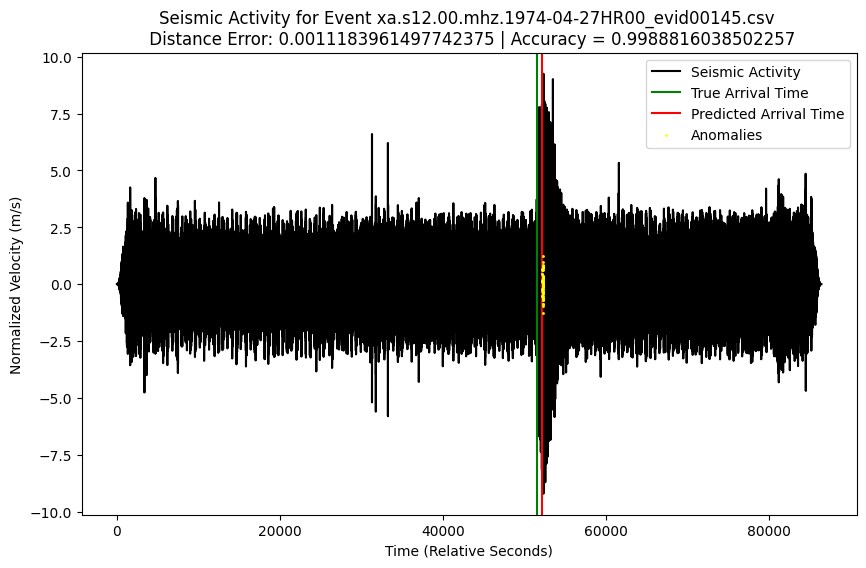

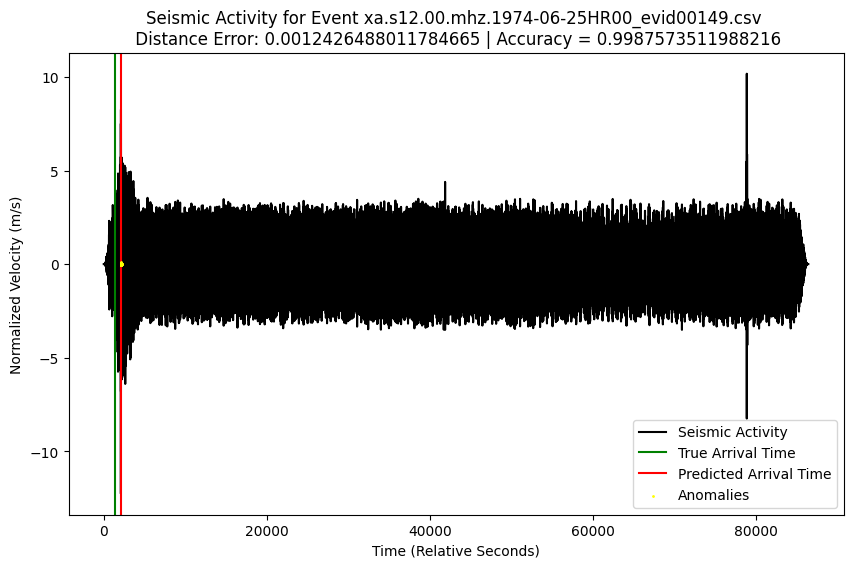

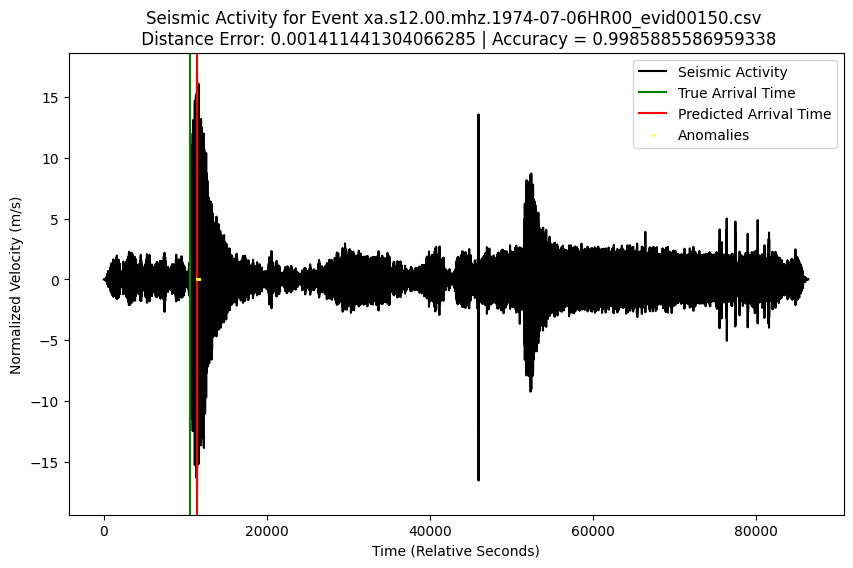

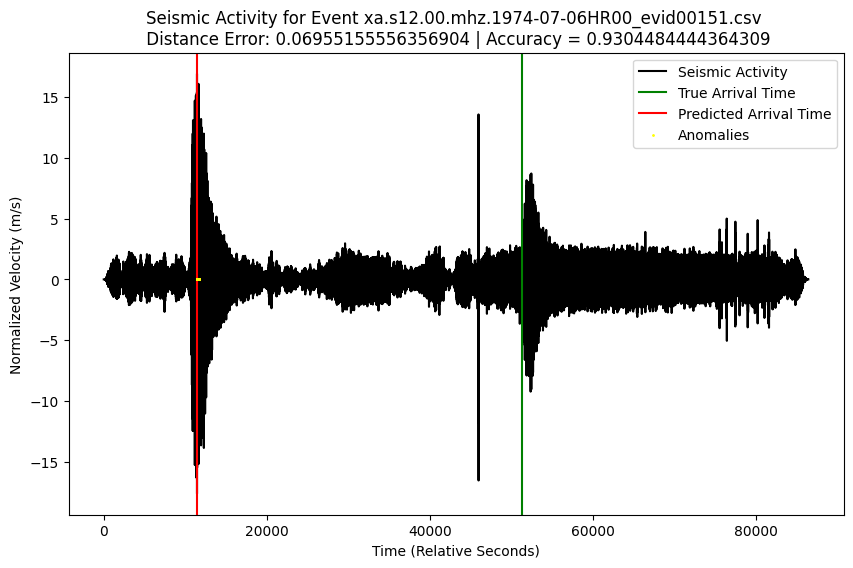

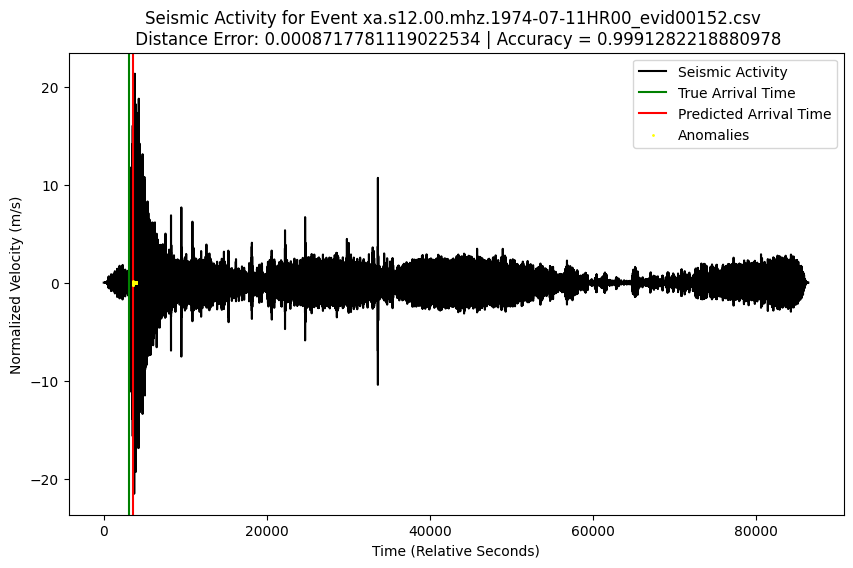

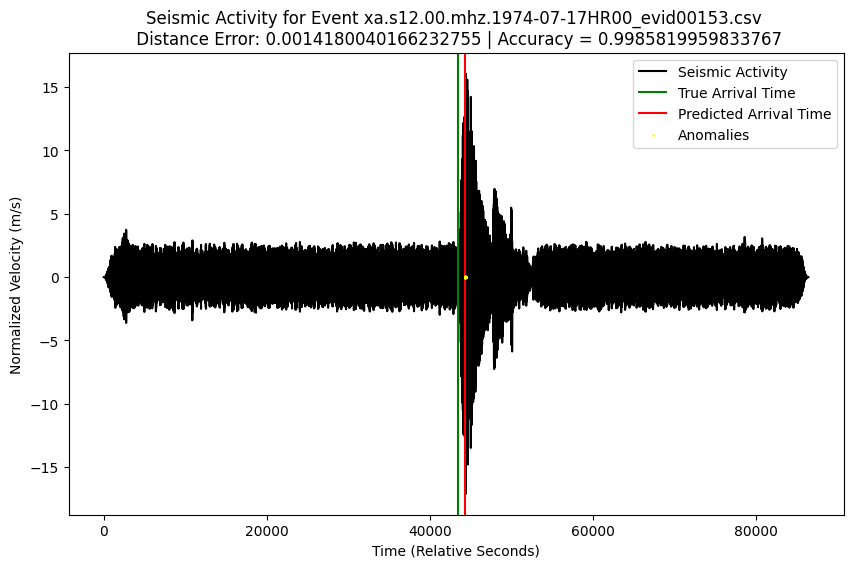

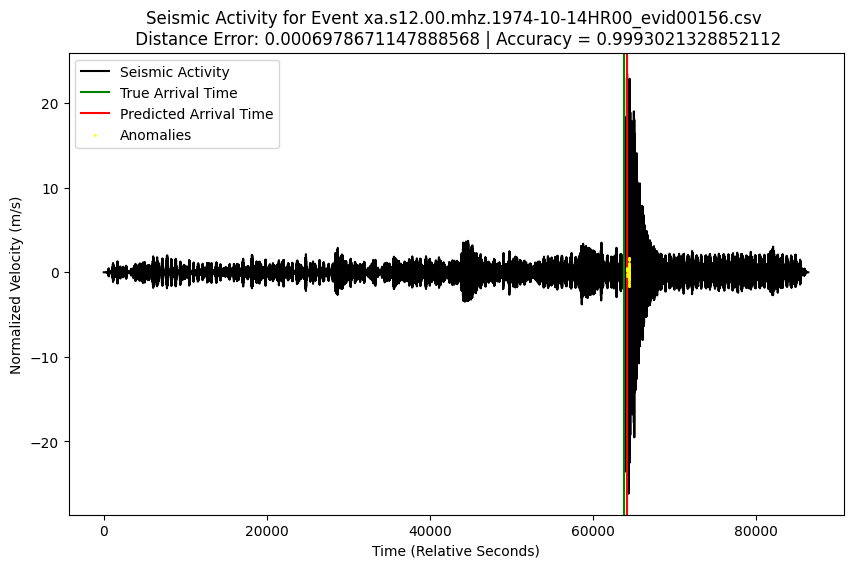

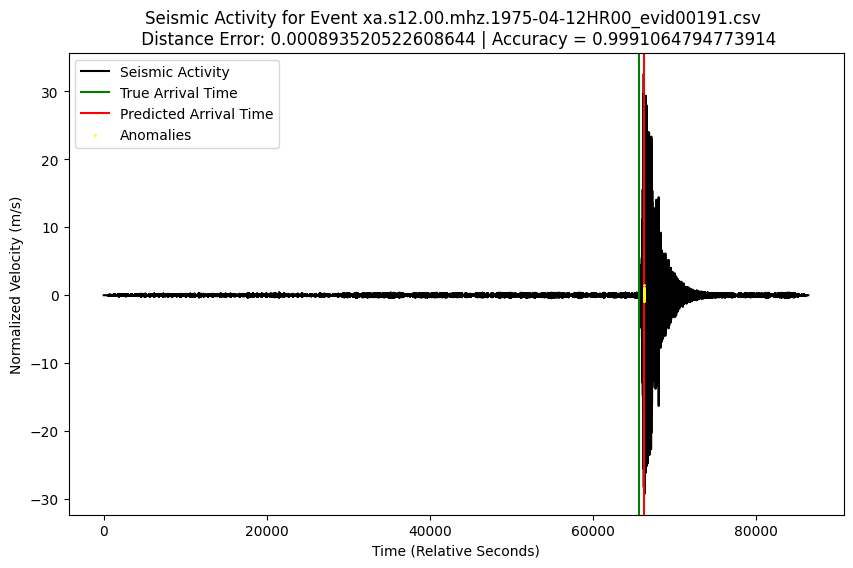

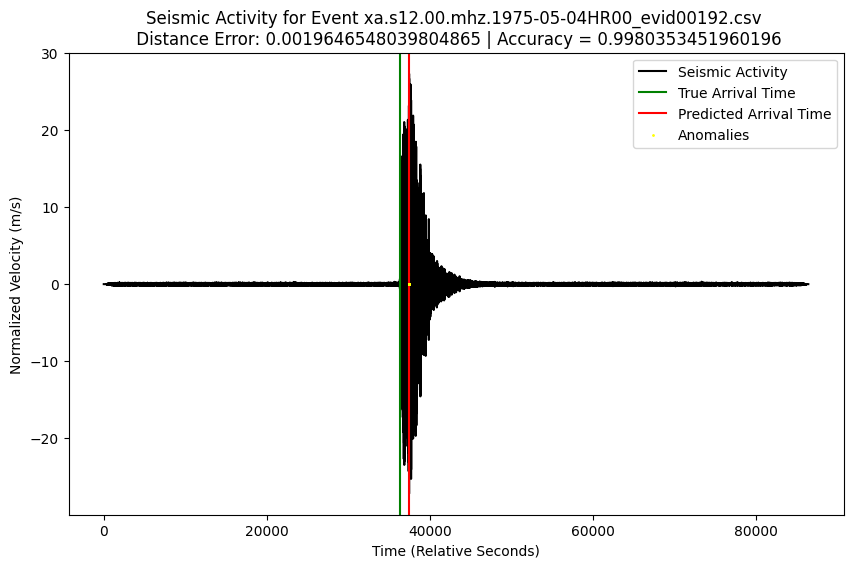

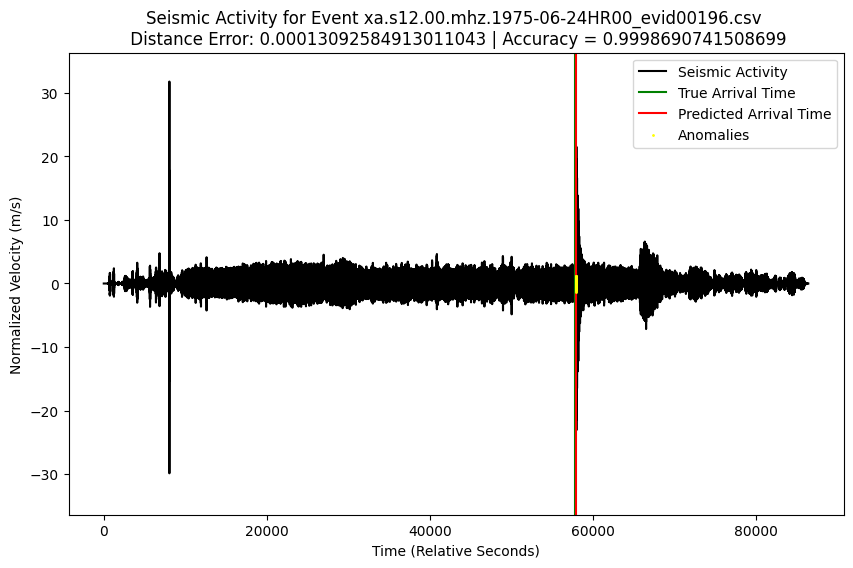

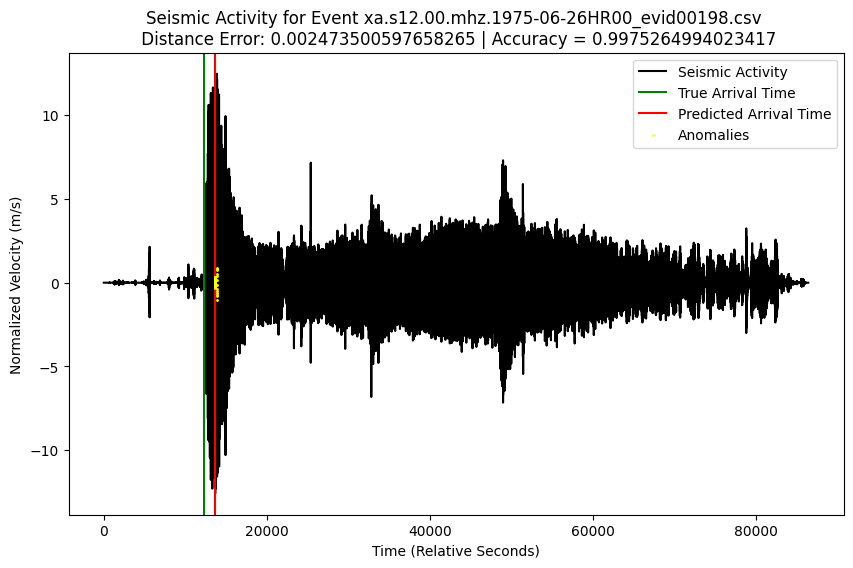

In [31]:
cumulative = 0
for i in event:
    length = lens_array[i]
    print(length)
    tiempo = time_arrays[i]
    X = data_arrays[i]

    plt.figure(figsize=(10, 6))
    plt.plot(
        tiempo,
        X,
        label="Seismic Activity",
        color="k",
    )

    error = mse[cumulative : cumulative + length]
    print(len(error))
    if moon:
        low = np.quantile(np.abs(error), 0.9999)
        # high = np.quantile(np.abs(mse), 0.998, method="weibull")
        anomalies_label = [1 if i > low else 0 for i in error]
        print("Predicted Anomaly Position:", np.argmax(anomalies_label))
        print(
            "Predicted Number of Anomalies:",
            np.count_nonzero(anomalies_label),
            "(depends directly on the quantile range)",
        )
    else:
        high = np.quantile(np.abs(error), 0.9999)
        anomalies_label = [1 if i > high else 0 for i in error]
        print("Predicted Anomaly Position:", np.argmax(anomalies_label))
        print(
            "Predicted Number of Anomalies:",
            np.count_nonzero(anomalies_label),
            "(depends directly on the quantile range)",
        )

    anomaly_indices = np.where(anomalies_label)[0]
    # anomaly_indices_in_event = np.array(
    #     [j for j in anomaly_indices if cumulative <= j and j <= cumulative + length]
    # )
    # print("Anomaly Indices in Event:", anomaly_indices_in_event)

    if train:
        true_arrival_line = plt.axvline(
            x=true_anomaly_time[i], c="green", label="True Arrival Time"
        )
        distance_error = (
            np.abs(true_anomaly_time[i] - anomaly_indices[0] / freq) / length
        )
        title = f"Seismic Activity for Event {event_filename[i]} \n Distance Error: {distance_error} | Accuracy = {1 - distance_error}"

    predicted_arrival_line = plt.axvline(
        x=anomaly_indices[0] / freq,
        c="red",
        label="Predicted Arrival Time",
    )

    if moon:
        plt.title(title if train else f"Seismic Activity for Event {event_filename[i]}")
        plt.xlabel("Time (Relative Seconds)")
        plt.ylabel("Normalized Velocity (m/s)")
        plt.legend()
        if train:
            plt.savefig(f"../../predictions/cnn/lunar/train/{event_filename[i]}.png")
        else:
            plt.savefig(
                f"../../predictions/cnn/lunar/test/{test_set}/{event_filename[i]}.png"
            )
    else:
        plt.title(title if train else f"Seismic Activity for Event {event_filename[i]}")
        plt.xlabel("Time (Relative Seconds)")
        plt.ylabel("Normalized Velocity (c/s)")
        plt.legend()
        if train:
            plt.savefig(f"../../predictions/cnn/mars/train/{event_filename[i]}.png")
        else:
            plt.savefig(f"../../predictions/cnn/mars/test/{event_filename[i]}.png")

    plt.scatter(
        time_array[anomaly_indices + windows_size],
        data_array[anomaly_indices + windows_size],
        color="yellow",
        label="Anomalies",
        marker="o",
        s=1,
        zorder=2,
    )

    if moon:
        plt.title(title if train else f"Seismic Activity for Event {event_filename[i]}")
        plt.xlabel("Time (Relative Seconds)")
        plt.ylabel("Normalized Velocity (m/s)")
        plt.legend()
        if train:
            plt.savefig(
                f"../../predictions/cnn/lunar/train/{event_filename[i]}_with_scatter.png"
            )
        else:
            plt.savefig(
                f"../../predictions/cnn/lunar/test/{test_set}/{event_filename[i]}_with_scatter.png"
            )
    else:
        plt.title(title if train else f"Seismic Activity for Event {event_filename[i]}")
        plt.xlabel("Time (Relative Seconds)")
        plt.ylabel("Normalized Velocity (c/s)")
        plt.legend()
        if train:
            plt.savefig(
                f"../../predictions/cnn/mars/train/{event_filename[i]}_with_scatter.png"
            )
        else:
            plt.savefig(
                f"../../predictions/cnn/mars/test/{event_filename[i]}_with_scatter.png"
            )

    cumulative += length

## EXTRA: Confusion Matrix

Not really valid...


In [22]:
# conf_matrix = confusion_matrix(y, anomalies_label)

# display = ConfusionMatrixDisplay(
#     confusion_matrix=conf_matrix, display_labels=["Normal", "Anomaly"]
# )

# display.plot(cmap=plt.cm.Blues)
# plt.title("Confusion Matrix for Anomaly Detection")
# plt.show()

# Extract Model


In [ ]:
if train:
    if use_processed_data:
        if moon:
            model.save(
                f"../../trained_models/lunar/cnn_sigmoid_moon_processed__events{input_model_training_size}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.keras"
            )
            model.save(
                f"../../trained_models/lunar/cnn_sigmoid_moon_processed__events{input_model_training_size}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.h5"
            )
        else:
            model.save(
                f"../../trained_models/mars/cnn_sigmoid_mars_processed__events{input_model_training_size}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.keras"
            )
            model.save(
                f"../../trained_models/mars/cnn_sigmoid_mars_processed__events{input_model_training_size}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.h5"
            )

    else:
        if moon:
            model.save(
                f"../../trained_models/lunar/cnn_sigmoid_moon__events{input_model_training_size}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.keras"
            )
            model.save(
                f"../../trained_models/lunar/cnn_sigmoid_moon__events{input_model_training_size}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.h5"
            )
        else:
            model.save(
                f"../../trained_models/mars/cnn_sigmoid_mars__events{input_model_training_size}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.keras"
            )
            model.save(
                f"../../trained_models/mars/cnn_sigmoid_mars__events{input_model_training_size}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.h5"
            )

# Extract Data


In [32]:
cumulative = 0
for i in range(len(event_filename)):
    length = lens_array[i]
    absolute = time_abs_arrays[i]
    tiempo = time_arrays[i]
    X = data_arrays[i]

    if train:
        true_anomaly_indices = np.zeros(length)
        true_anomaly_indices[int(true_anomaly_time[i] * freq)] = 1

    error = mse[cumulative : cumulative + length]
    if moon:
        low = np.quantile(np.abs(error), 0.9999)
        predicted_anomalies_label = [1 if i > low else 0 for i in error]
    else:
        high = np.quantile(np.abs(error), 0.9999)
        predicted_anomalies_label = [1 if i > high else 0 for i in error]

    predicted_anomaly_indices = np.where(predicted_anomalies_label)[0]
    print(predicted_anomaly_indices)

    if use_processed_data:
        if train:
            results = pd.DataFrame(
                {
                    "time_abs(%Y-%m-%dT%H:%M:%S.%f)": absolute,
                    "time_rel(sec)": tiempo,
                    "velocity(m/s)": X,
                    "true_arrival_time": true_anomaly_indices,
                    "predicted_arrival_time": [
                        1 if index in predicted_anomaly_indices else 0
                        for index in range(length)
                    ],
                }
            )

            if moon:
                results.to_csv(
                    f"../../predictions/cnn/lunar/train/{event_filename[i]}__results_processed__events{input_model_training_size}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.csv",
                    index=False,
                )
            else:
                results.to_csv(
                    f"../../predictions/cnn/mars/train/{event_filename[i]}__results_processed__events{input_model_training_size}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.csv",
                    index=False,
                )

        else:
            results = pd.DataFrame(
                {
                    "time_abs(%Y-%m-%dT%H:%M:%S.%f)": absolute,
                    "time_rel(sec)": tiempo,
                    "velocity(m/s)": X,
                    "predicted_arrival_time": [
                        1 if i in predicted_anomaly_indices else 0
                        for i in range(length)
                    ],
                }
            )
            if moon:
                results.to_csv(
                    f"../../predictions/cnn/lunar/test/{test_set}{event_filename[i]}__results_processed__events{input_model_training_size}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.csv",
                    index=False,
                )
            else:
                results.to_csv(
                    f"../../predictions/cnn/mars/test/{event_filename[i]}__results_processed__events{input_model_training_size}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.csv",
                    index=False,
                )

    else:
        if train:
            results = pd.DataFrame(
                {
                    "time_abs(%Y-%m-%dT%H:%M:%S.%f)": absolute,
                    "time_rel(sec)": tiempo,
                    "velocity(m/s)": X,
                    "true_arrival_time": true_anomaly_indices,
                    "predicted_arrival_time": [
                        1 if i in predicted_anomaly_indices else 0
                        for i in range(length)
                    ],
                }
            )

            if moon:
                results.to_csv(
                    f"../../predictions/cnn/lunar/train/{event_filename[i]}__results__events{input_model_training_size}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.csv",
                    index=False,
                )
            else:
                results.to_csv(
                    f"../../predictions/cnn/mars/train/{event_filename[i]}__results__events{input_model_training_size}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.csv",
                    index=False,
                )

        else:
            results = pd.DataFrame(
                {
                    "time_abs(%Y-%m-%dT%H:%M:%S.%f)": absolute,
                    "time_rel(sec)": tiempo,
                    "velocity(m/s)": X,
                    "predicted_arrival_time": [
                        1 if i in predicted_anomaly_indices else 0
                        for i in range(length)
                    ],
                }
            )

            if moon:
                results.to_csv(
                    f"../../predictions/cnn/lunar/test/{test_set}{event_filename[i]}__results__events{input_model_training_size}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.csv",
                    index=False,
                )
            else:
                results.to_csv(
                    f"../../predictions/cnn/mars/test/{event_filename[i]}__results__events{input_model_training_size}_windowsize{windows_size}_batchsize{batch_size}_smoothing{label_smoothing}_epochs{n_epochs}.csv",
                    index=False,
                )

    cumulative += length

[488377 488782 488785 488786 488787 488788 488789 488790 488791 488792
 488793 488794 488795 488796 488797 488798 488799 488800 488801 488802
 488803 490073 490074 490075 490076 490077 490078 490079 490080 490081
 490082 490083 490084 490085 490086 490087 490088 490089 490090 490091
 490092 490093 490094 490095 490096 490097 490131 490134 490135 490136
 490141 490162 490163 490164 490165 490166 490167 490168]
[89034 89035 89036 89037 89038 89039 89040 89041 89042 89043 89044 89045
 89046 89047 89048 89049 89050 89051 89052 89053 89054 89055 89056 89057
 89058 89059 89060 89061 89062 89063 89064 89065 89066 89067 89068 89069
 89070 89071 89072 89876 89877 89878 89983 89984 89985 89986 89987 89988
 89989 89990 89991 89992 89993 89994 89995 89996 89997 89998]
[486453 486454 486457 486458 486459 486460 487341 487342 487343 487344
 487345 487346 487347 487348 487349 487350 487351 487352 487353 487354
 487355 487356 487357 487358 487359 487360 487361 487362 487363 487364
 487365 487366 48736